<a href="https://colab.research.google.com/github/ASWINRAJEEVMV/QubitTech/blob/main/NHSML%26trendanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print("Libraries loaded!")

Libraries loaded!


In [ ]:
FILE = '/content/drive/MyDrive/NHS_Data.xlsx'

xl = pd.ExcelFile(FILE)

skip_sheets = ['Sheet2', 'Sheet3', 'Master', 'Copy of Master',
               'Region Wise Split', 'Org Code to Org Name Mapping',
               'Return Definitions']

monthly_sheets = [s for s in xl.sheet_names if s not in skip_sheets]

print("File loaded!")
print("Monthly sheets found:", len(monthly_sheets))

File loaded!
Monthly sheets found: 49


In [ ]:
selected_cols = [
    'Period', 'Org Code', 'Parent Org', 'Org name',
    'A&E attendances Type 1',
    'A&E attendances Type 2',
    'A&E attendances Other A&E Department',
    'Attendances over 4hrs Type 1',
    'Attendances over 4hrs Type 2',
    'Attendances over 4hrs Other Department',
    'Patients who have waited 4-12 hs from DTA to admission',
    'Patients who have waited 12+ hrs from DTA to admission',
    'Emergency admissions via A&E - Type 1'
]

all_data = []
for sheet in monthly_sheets:
    df = pd.read_excel(FILE, sheet_name=sheet)
    cols_to_use = [c for c in selected_cols if c in df.columns]
    df = df[cols_to_use].copy()
    all_data.append(df)

master = pd.concat(all_data, ignore_index=True)

print("Master dataset created!")
print("Total rows:", master.shape[0])
print("Total columns:", master.shape[1])

Master dataset created!
Total rows: 9897
Total columns: 13


In [ ]:
# Remove TOTAL rows before converting dates
master = master[master['Period'] != 'TOTAL']
master = master[master['Period'].notna()]

# Convert Period to datetime
master['Period'] = pd.to_datetime(master['Period'], errors='coerce')

# Remove failed date conversions
master = master[master['Period'].notna()]

# Remove Total region rows
master = master[master['Parent Org'] != 'Total']

# Fill blanks with 0
master.fillna(0, inplace=True)

# Rename columns
master.rename(columns={
    'Parent Org': 'Region',
    'A&E attendances Type 1': 'AE_T1',
    'A&E attendances Type 2': 'AE_T2',
    'A&E attendances Other A&E Department': 'AE_Other',
    'Attendances over 4hrs Type 1': 'Over4hr_T1',
    'Attendances over 4hrs Type 2': 'Over4hr_T2',
    'Attendances over 4hrs Other Department': 'Over4hr_Other',
    'Patients who have waited 4-12 hs from DTA to admission': 'Wait_4to12hr_raw',
    'Patients who have waited 12+ hrs from DTA to admission': 'Wait_12plus',
    'Emergency admissions via A&E - Type 1': 'Emerg_Admissions'
}, inplace=True)

# Fix double counting — create clean 4-12hr bucket
master['Wait_4to12hr'] = (master['Over4hr_T1'] - master['Wait_12plus']).clip(lower=0)

master = master.sort_values('Period').reset_index(drop=True)

print("Data cleaned!")
print("Date range:", master['Period'].min().strftime('%b-%Y'),
      "to", master['Period'].max().strftime('%b-%Y'))
print("Unique Trusts:", master['Org Code'].nunique())
print("Regions:", master['Region'].unique())

Data cleaned!
Date range: Jan-2022 to Jan-2026
Unique Trusts: 221
Regions: ['NHS ENGLAND SOUTH WEST' 'NHS ENGLAND NORTH EAST AND YORKSHIRE'
 'NHS ENGLAND EAST OF ENGLAND' 'NHS ENGLAND NORTH WEST'
 'NHS ENGLAND MIDLANDS' 'NHS ENGLAND LONDON' 'NHS ENGLAND SOUTH EAST']


In [ ]:
monthly = master.groupby('Period').agg(
    AE_T1=('AE_T1', 'sum'),
    AE_T2=('AE_T2', 'sum'),
    AE_Other=('AE_Other', 'sum'),
    Over4hr_T1=('Over4hr_T1', 'sum'),
    Over4hr_T2=('Over4hr_T2', 'sum'),
    Over4hr_Other=('Over4hr_Other', 'sum'),
    Wait_4to12hr=('Wait_4to12hr', 'sum'),
    Wait_12plus=('Wait_12plus', 'sum'),
    Emerg_Admissions=('Emerg_Admissions', 'sum')
).reset_index()

# Total A&E all types
monthly['AE_Total'] = monthly['AE_T1'] + monthly['AE_T2'] + monthly['AE_Other']

# 4 hour breach rate
monthly['Breach_Rate'] = (monthly['Over4hr_T1'] / monthly['AE_T1'] * 100).round(2)

# Month label
monthly['Month_Label'] = monthly['Period'].dt.strftime('%b-%y')

# Verify no double counting
monthly['Verify'] = monthly['Wait_4to12hr'] + monthly['Wait_12plus']

print("Monthly totals done!")
print("Months:", len(monthly))
print()
print("Double counting check:")
print(monthly[['Month_Label','Over4hr_T1','Wait_4to12hr','Wait_12plus','Verify']].tail(5).to_string())
print()
print("Over4hr_T1 should equal Verify column!")

Monthly totals done!
Months: 49

Double counting check:
   Month_Label  Over4hr_T1  Wait_4to12hr  Wait_12plus  Verify
44      Sep-25      543443        498678        44765  543443
45      Oct-25      581850        527536        54314  581850
46      Nov-25      566410        515762        50648  566410
47      Dec-25      572137        521362        50775  572137
48      Jan-26      603393        531876        71517  603393

Over4hr_T1 should equal Verify column!


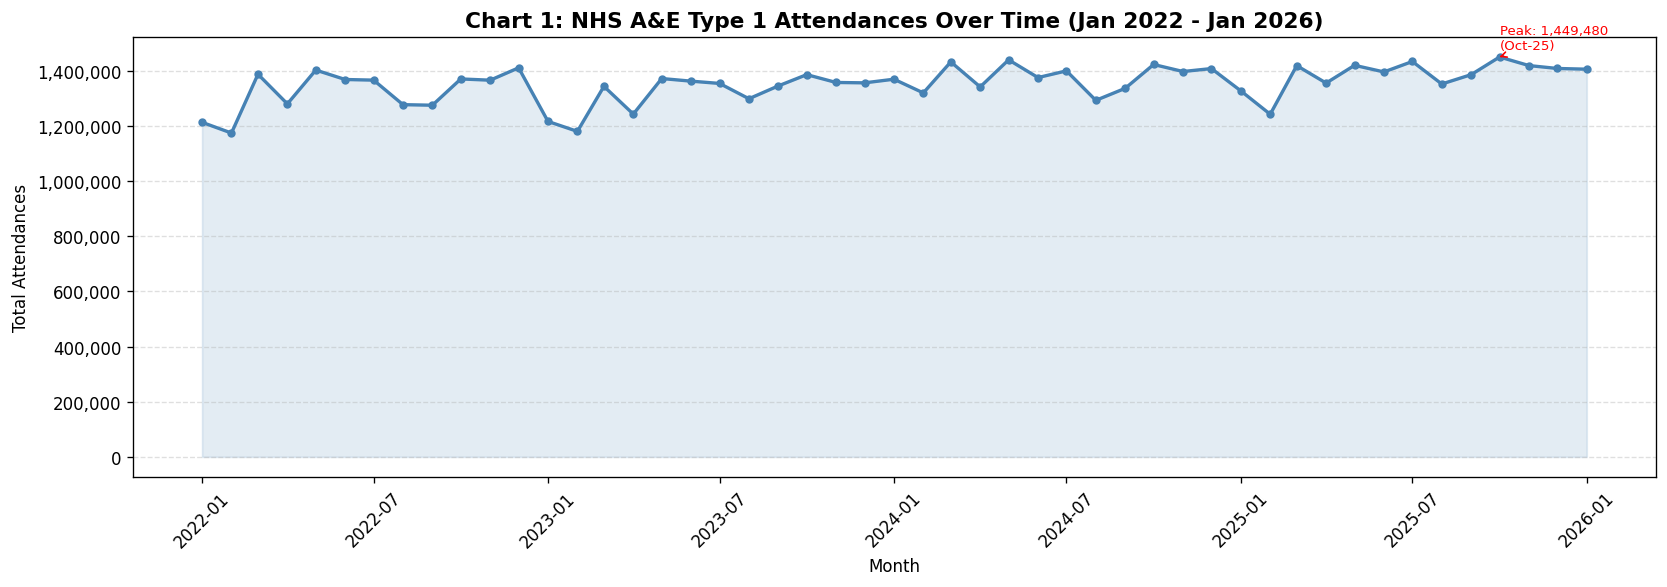

Chart 1 done!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['AE_T1'], color='steelblue',
        linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['Period'], monthly['AE_T1'], alpha=0.15, color='steelblue')

peak = monthly.loc[monthly['AE_T1'].idxmax()]
ax.annotate(f"Peak: {int(peak['AE_T1']):,}\n({peak['Month_Label']})",
            xy=(peak['Period'], peak['AE_T1']),
            xytext=(peak['Period'], peak['AE_T1']*1.02),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')

ax.set_title('Chart 1: NHS A&E Type 1 Attendances Over Time (Jan 2022 - Jan 2026)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Attendances')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart1_ae_attendances.png', bbox_inches='tight')
plt.show()
print("Chart 1 done!")

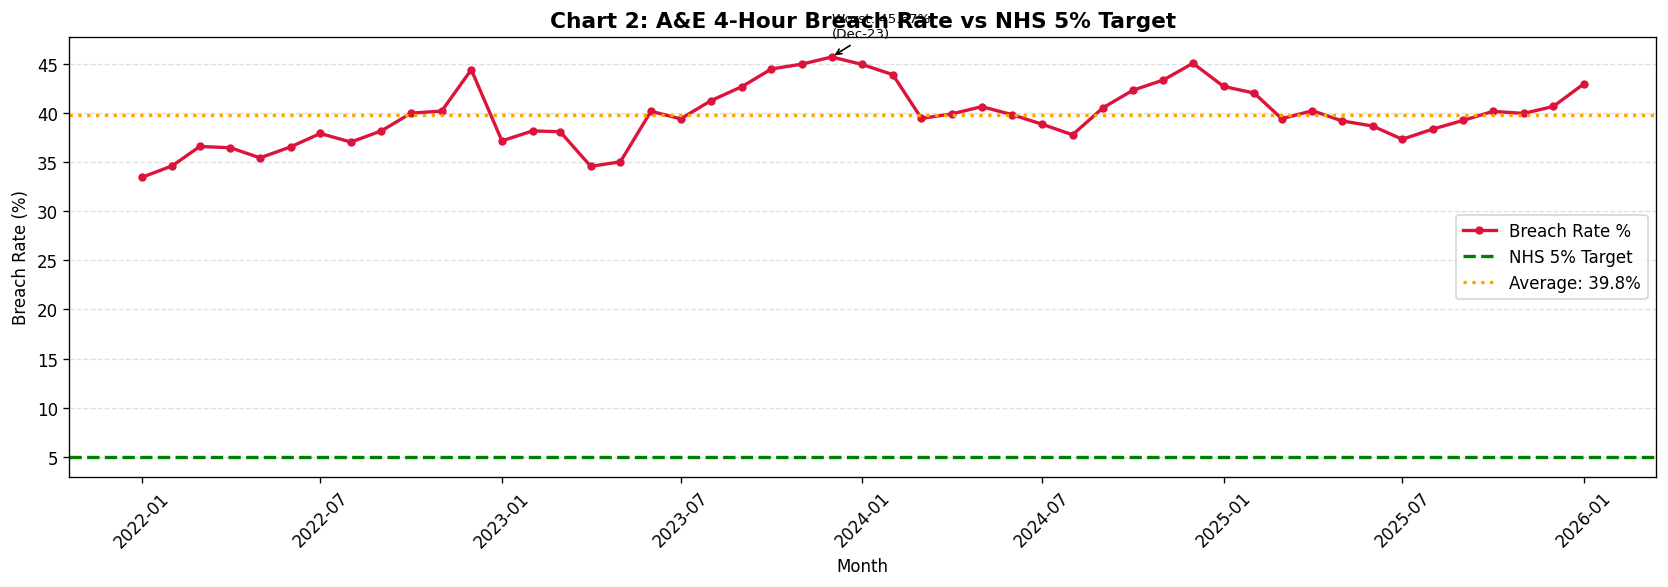

Chart 2 done!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['Breach_Rate'], color='crimson',
        linewidth=2, marker='o', markersize=4, label='Breach Rate %')
ax.axhline(y=5, color='green', linestyle='--', linewidth=2, label='NHS 5% Target')
avg = monthly['Breach_Rate'].mean()
ax.axhline(y=avg, color='orange', linestyle=':', linewidth=2,
           label='Average: ' + str(round(avg,1)) + '%')

worst = monthly.loc[monthly['Breach_Rate'].idxmax()]
ax.annotate(f"Worst: {worst['Breach_Rate']}%\n({worst['Month_Label']})",
            xy=(worst['Period'], worst['Breach_Rate']),
            xytext=(worst['Period'], worst['Breach_Rate']+2),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)

ax.set_title('Chart 2: A&E 4-Hour Breach Rate vs NHS 5% Target',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Breach Rate (%)')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart2_breach_rate.png', bbox_inches='tight')
plt.show()
print("Chart 2 done!")

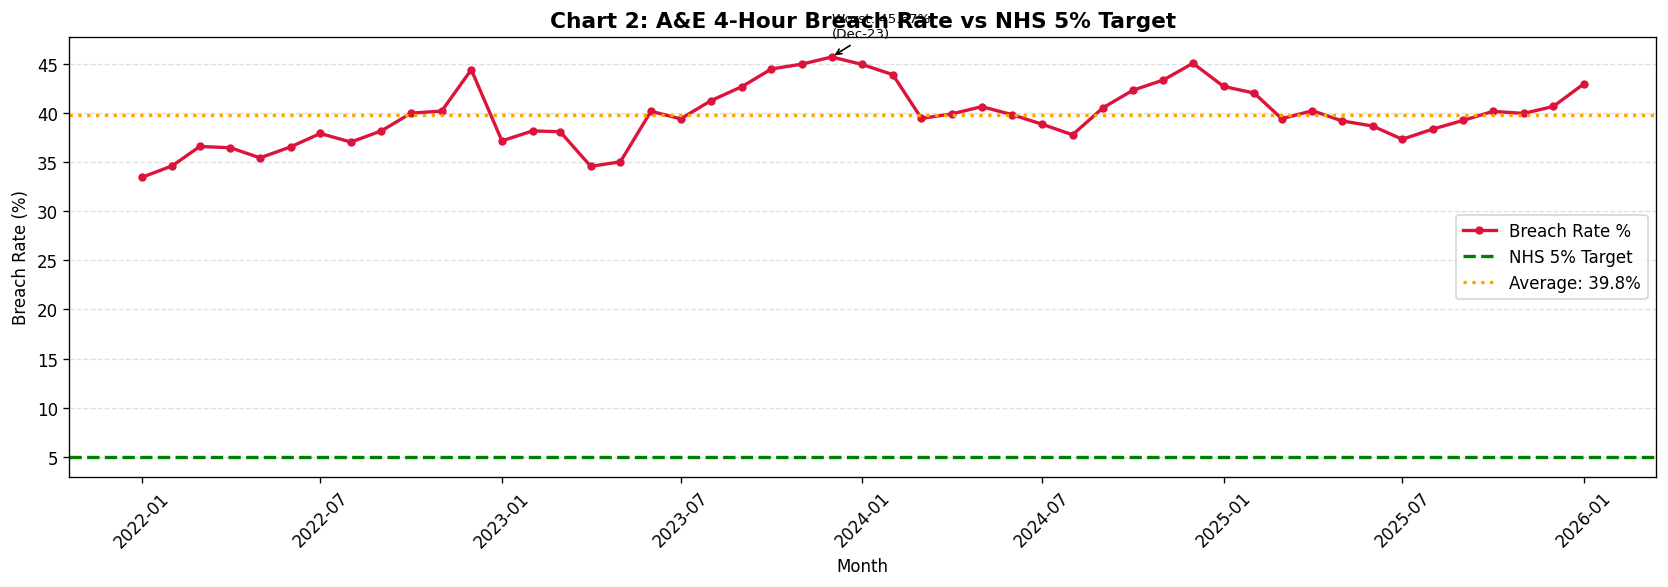

Chart 2 done!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['Breach_Rate'], color='crimson',
        linewidth=2, marker='o', markersize=4, label='Breach Rate %')
ax.axhline(y=5, color='green', linestyle='--', linewidth=2, label='NHS 5% Target')
avg = monthly['Breach_Rate'].mean()
ax.axhline(y=avg, color='orange', linestyle=':', linewidth=2,
           label='Average: ' + str(round(avg,1)) + '%')

worst = monthly.loc[monthly['Breach_Rate'].idxmax()]
ax.annotate(f"Worst: {worst['Breach_Rate']}%\n({worst['Month_Label']})",
            xy=(worst['Period'], worst['Breach_Rate']),
            xytext=(worst['Period'], worst['Breach_Rate']+2),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)

ax.set_title('Chart 2: A&E 4-Hour Breach Rate vs NHS 5% Target',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Breach Rate (%)')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart2_breach_rate.png', bbox_inches='tight')
plt.show()
print("Chart 2 done!")

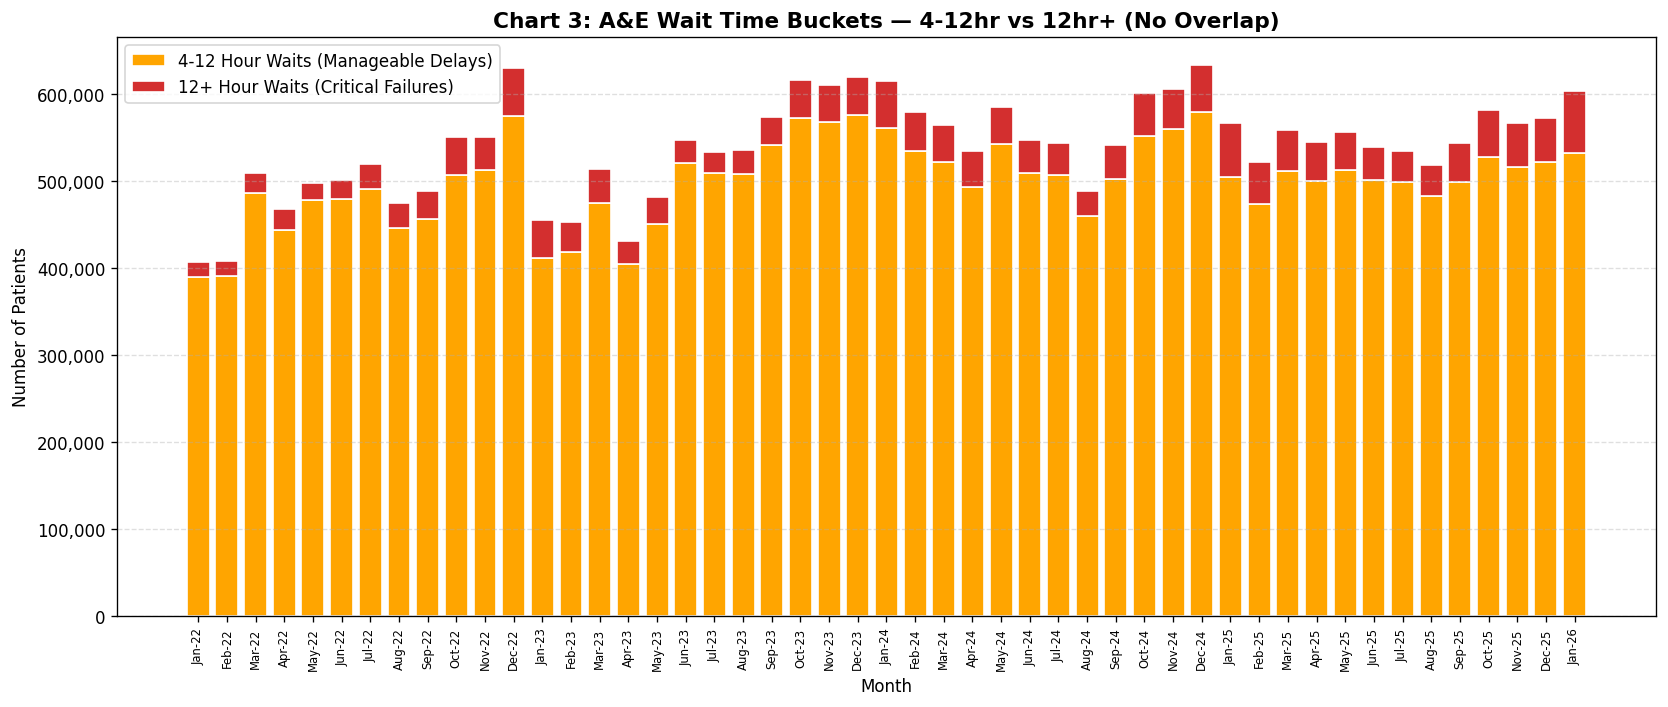

Chart 3 done!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Orange = 4-12hr waits (manageable delays)
ax.bar(monthly['Month_Label'], monthly['Wait_4to12hr'],
       color='#FFA500', label='4-12 Hour Waits (Manageable Delays)', edgecolor='white')

# Red = 12hr+ waits stacked on top (critical failures)
ax.bar(monthly['Month_Label'], monthly['Wait_12plus'],
       bottom=monthly['Wait_4to12hr'],
       color='#d32f2f', label='12+ Hour Waits (Critical Failures)', edgecolor='white')

ax.set_title('Chart 3: A&E Wait Time Buckets — 4-12hr vs 12hr+ (No Overlap)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Patients')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart3_wait_buckets.png', bbox_inches='tight')
plt.show()
print("Chart 3 done!")

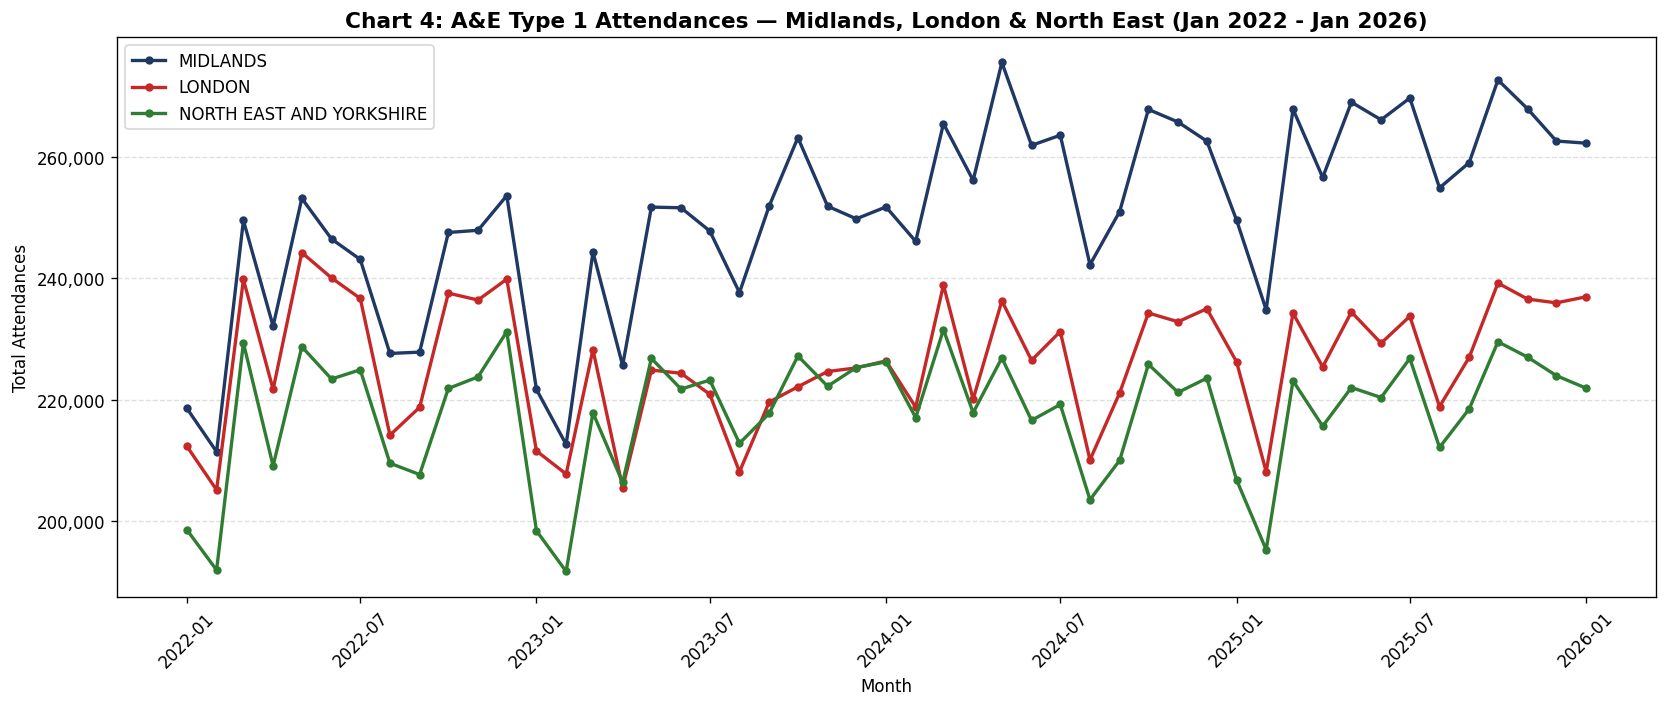

Chart 4 updated with 3 regions!


In [ ]:
three_regions = [
    'NHS ENGLAND MIDLANDS',
    'NHS ENGLAND LONDON',
    'NHS ENGLAND NORTH EAST AND YORKSHIRE'
]

regional = master.groupby(['Period','Region'])['AE_T1'].sum().reset_index()
regional = regional[regional['Region'].isin(three_regions)]

fig, ax = plt.subplots(figsize=(14, 6))
colors_r = ['#1F3864', '#C62828', '#2E7D32']

for i, region in enumerate(three_regions):
    rdf = regional[regional['Region'] == region]
    short = region.replace('NHS ENGLAND ', '')
    ax.plot(rdf['Period'], rdf['AE_T1'], label=short,
            linewidth=2, marker='o', markersize=4, color=colors_r[i])

ax.set_title('Chart 4: A&E Type 1 Attendances — Midlands, London & North East (Jan 2022 - Jan 2026)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Attendances')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart4_regional.png', bbox_inches='tight')
plt.show()
print("Chart 4 updated with 3 regions!")

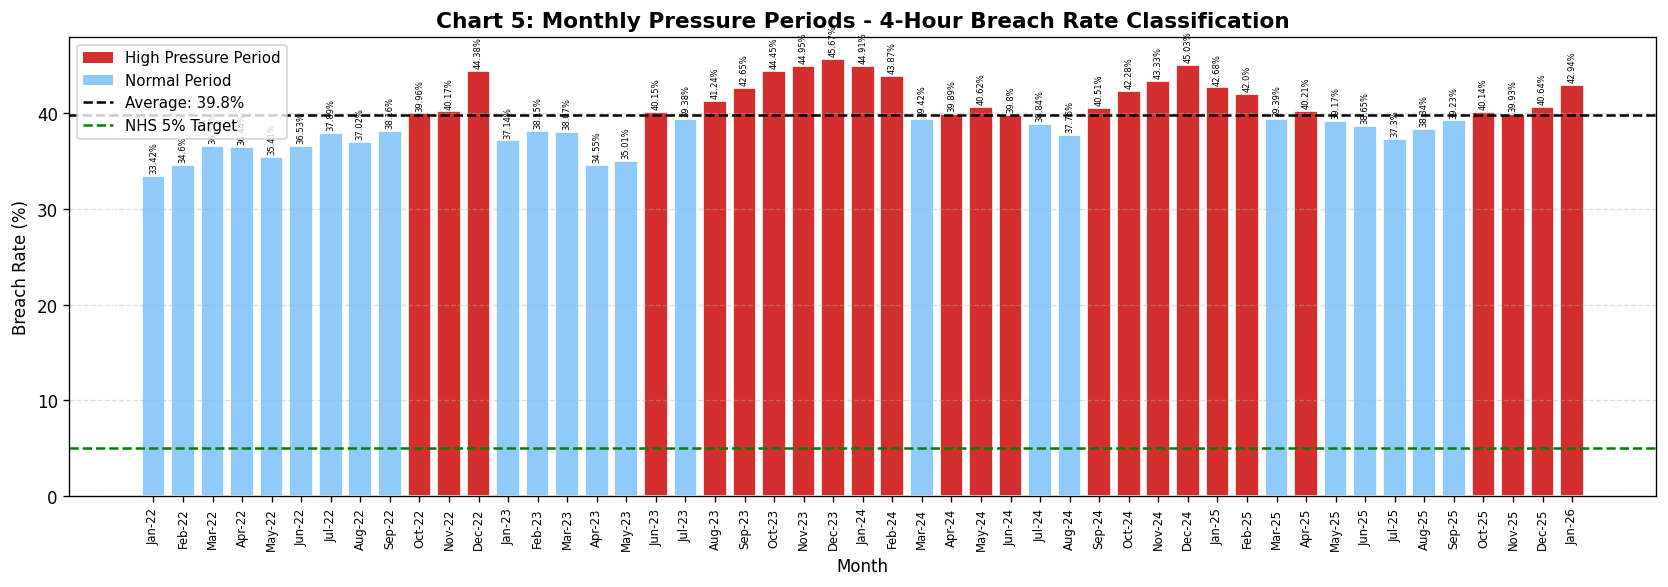

High pressure months: ['Oct-22', 'Nov-22', 'Dec-22', 'Jun-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Apr-24', 'May-24', 'Jun-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Apr-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26']
Chart 5 done!


In [ ]:
from matplotlib.patches import Patch

avg_breach = monthly['Breach_Rate'].mean()
monthly['Pressure'] = monthly['Breach_Rate'] > avg_breach
bar_colors = ['#d32f2f' if p else '#90caf9' for p in monthly['Pressure']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly['Month_Label'], monthly['Breach_Rate'],
              color=bar_colors, edgecolor='white')

# Add exact numbers on top of each bar
for bar, val in zip(bars, monthly['Breach_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val) + '%', ha='center', va='bottom', fontsize=5, rotation=90)

ax.axhline(avg_breach, color='black', linestyle='--', linewidth=1.5)
ax.axhline(5, color='green', linestyle='--', linewidth=1.5)

legend_elements = [
    Patch(facecolor='#d32f2f', label='High Pressure Period'),
    Patch(facecolor='#90caf9', label='Normal Period'),
    plt.Line2D([0],[0], color='black', linestyle='--',
               label='Average: ' + str(round(avg_breach,1)) + '%'),
    plt.Line2D([0],[0], color='green', linestyle='--', label='NHS 5% Target')
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_title('Chart 5: Monthly Pressure Periods - 4-Hour Breach Rate Classification',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Breach Rate (%)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart5_pressure_periods.png', bbox_inches='tight')
plt.show()

pressure_months = monthly[monthly['Pressure'] == True]['Month_Label'].tolist()
print("High pressure months:", pressure_months)
print("Chart 5 done!")

In [ ]:
peak_ae = monthly.loc[monthly['AE_T1'].idxmax()]
low_ae = monthly.loc[monthly['AE_T1'].idxmin()]
peak_breach = monthly.loc[monthly['Breach_Rate'].idxmax()]
peak_12hr = monthly.loc[monthly['Wait_12plus'].idxmax()]
peak_4to12 = monthly.loc[monthly['Wait_4to12hr'].idxmax()]
pct_above_target = (monthly['Breach_Rate'] > 5).sum()

print("TREND ANALYSIS - KEY INSIGHTS")
print("="*50)

print("\nINSIGHT 1 - DEMAND TREND")
print("Peak attendances:", int(peak_ae['AE_T1']), "in", peak_ae['Month_Label'])
print("Lowest attendances:", int(low_ae['AE_T1']), "in", low_ae['Month_Label'])

print("\nINSIGHT 2 - 4-HOUR PERFORMANCE")
print("Worst breach rate:", peak_breach['Breach_Rate'], "% in", peak_breach['Month_Label'])
print("Months above NHS 5% target:", pct_above_target, "out of", len(monthly))

print("\nINSIGHT 3 - WAIT TIME BUCKETS")
print("Peak 4-12hr waits:", int(peak_4to12['Wait_4to12hr']), "in", peak_4to12['Month_Label'])
print("Peak 12hr+ waits:", int(peak_12hr['Wait_12plus']), "in", peak_12hr['Month_Label'])
print("Jan-26 breakdown:")
jan26 = monthly[monthly['Month_Label'] == 'Jan-26'].iloc[0]
print("  4-12hr:", int(jan26['Wait_4to12hr']), "patients")
print("  12hr+:", int(jan26['Wait_12plus']), "patients")
print("  Total over 4hr:", int(jan26['Over4hr_T1']), "patients")

print("\nINSIGHT 4 - PRESSURE PERIODS")
print("High pressure months:", pressure_months)
print("Total high pressure:", len(pressure_months), "out of", len(monthly))

TREND ANALYSIS - KEY INSIGHTS

INSIGHT 1 - DEMAND TREND
Peak attendances: 1449480 in Oct-25
Lowest attendances: 1173861 in Feb-22

INSIGHT 2 - 4-HOUR PERFORMANCE
Worst breach rate: 45.67 % in Dec-23
Months above NHS 5% target: 49 out of 49

INSIGHT 3 - WAIT TIME BUCKETS
Peak 4-12hr waits: 579608 in Dec-24
Peak 12hr+ waits: 71517 in Jan-26
Jan-26 breakdown:
  4-12hr: 531876 patients
  12hr+: 71517 patients
  Total over 4hr: 603393 patients

INSIGHT 4 - PRESSURE PERIODS
High pressure months: ['Oct-22', 'Nov-22', 'Dec-22', 'Jun-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Apr-24', 'May-24', 'Jun-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Apr-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26']
Total high pressure: 25 out of 49


In [ ]:
three_regions = [
    'NHS ENGLAND MIDLANDS',
    'NHS ENGLAND LONDON',
    'NHS ENGLAND NORTH EAST AND YORKSHIRE'
]

# Filter master to only 3 regions
master_3r = master[master['Region'].isin(three_regions)].copy()

# Create monthly totals for 3 regions only
monthly_3r = master_3r.groupby('Period').agg(
    AE_T1=('AE_T1', 'sum'),
    AE_T2=('AE_T2', 'sum'),
    AE_Other=('AE_Other', 'sum'),
    Over4hr_T1=('Over4hr_T1', 'sum'),
    Wait_4to12hr=('Wait_4to12hr', 'sum'),
    Wait_12plus=('Wait_12plus', 'sum'),
    Emerg_Admissions=('Emerg_Admissions', 'sum')
).reset_index()

monthly_3r['AE_Total'] = monthly_3r['AE_T1'] + monthly_3r['AE_T2'] + monthly_3r['AE_Other']
monthly_3r['Breach_Rate'] = (monthly_3r['Over4hr_T1'] / monthly_3r['AE_T1'] * 100).round(2)
monthly_3r['Month_Label'] = monthly_3r['Period'].dt.strftime('%b-%y')

print("3 Region dataset ready!")
print("Regions included:", master_3r['Region'].unique())
print(monthly_3r[['Month_Label','AE_T1','Breach_Rate','Wait_4to12hr','Wait_12plus']].tail(5).to_string())

3 Region dataset ready!
Regions included: ['NHS ENGLAND NORTH EAST AND YORKSHIRE' 'NHS ENGLAND MIDLANDS'
 'NHS ENGLAND LONDON']
   Month_Label   AE_T1  Breach_Rate  Wait_4to12hr  Wait_12plus
44      Sep-25  704516        39.17        252915        23062
45      Oct-25  741357        39.97        267884        28469
46      Nov-25  731440        40.14        267604        25994
47      Dec-25  722489        40.76        268609        25853
48      Jan-26  721078        42.78        271794        36653


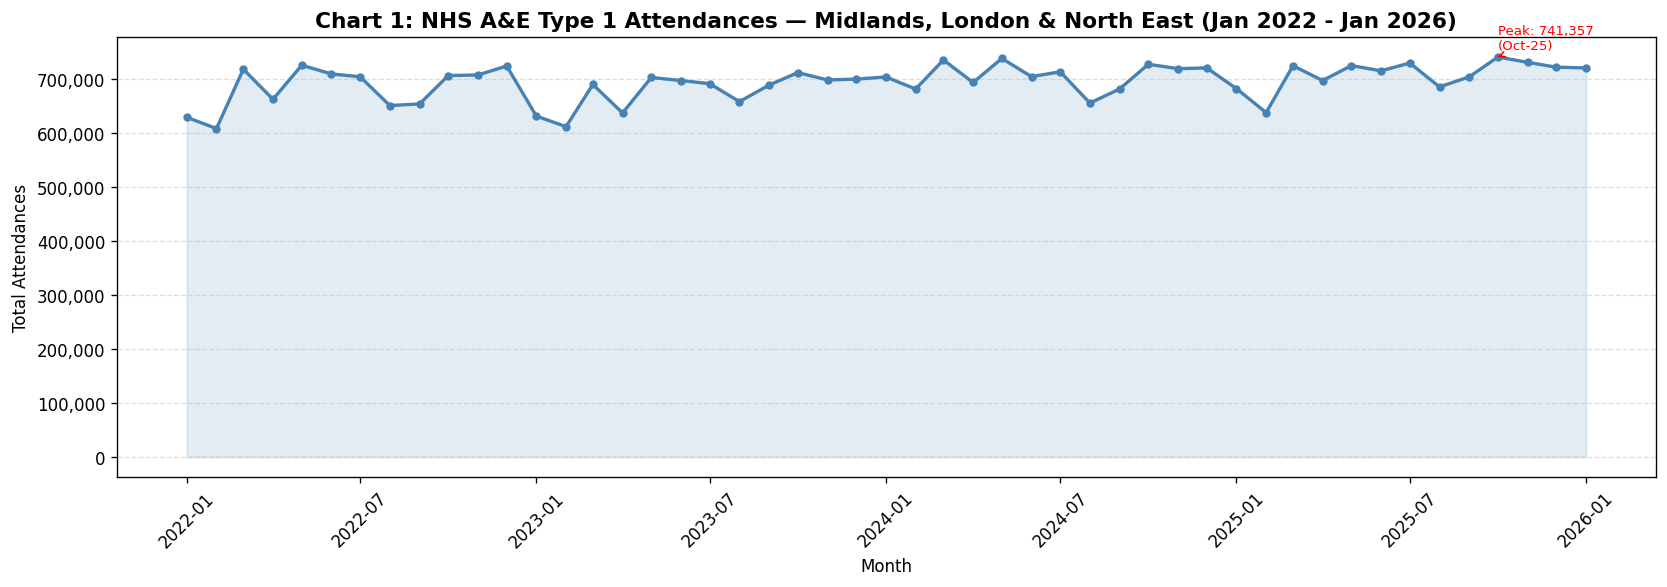

Chart 1 updated!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_3r['Period'], monthly_3r['AE_T1'],
        color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_3r['Period'], monthly_3r['AE_T1'], alpha=0.15, color='steelblue')

peak = monthly_3r.loc[monthly_3r['AE_T1'].idxmax()]
ax.annotate(f"Peak: {int(peak['AE_T1']):,}\n({peak['Month_Label']})",
            xy=(peak['Period'], peak['AE_T1']),
            xytext=(peak['Period'], peak['AE_T1']*1.02),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')

ax.set_title('Chart 1: NHS A&E Type 1 Attendances — Midlands, London & North East (Jan 2022 - Jan 2026)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Attendances')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart1_ae_attendances.png', bbox_inches='tight')
plt.show()
print("Chart 1 updated!")

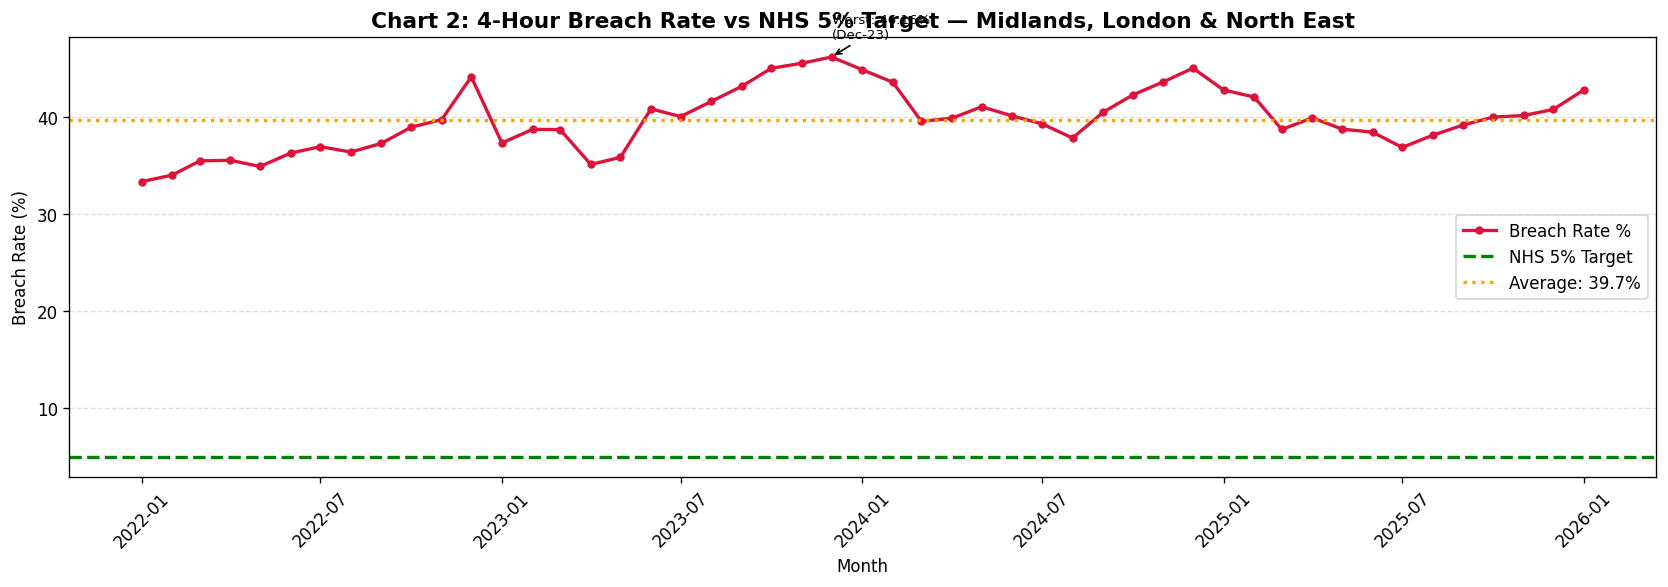

Chart 2 updated!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_3r['Period'], monthly_3r['Breach_Rate'], color='crimson',
        linewidth=2, marker='o', markersize=4, label='Breach Rate %')
ax.axhline(y=5, color='green', linestyle='--', linewidth=2, label='NHS 5% Target')
avg = monthly_3r['Breach_Rate'].mean()
ax.axhline(y=avg, color='orange', linestyle=':', linewidth=2,
           label='Average: ' + str(round(avg,1)) + '%')

worst = monthly_3r.loc[monthly_3r['Breach_Rate'].idxmax()]
ax.annotate(f"Worst: {worst['Breach_Rate']}%\n({worst['Month_Label']})",
            xy=(worst['Period'], worst['Breach_Rate']),
            xytext=(worst['Period'], worst['Breach_Rate']+2),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)

ax.set_title('Chart 2: 4-Hour Breach Rate vs NHS 5% Target — Midlands, London & North East',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Breach Rate (%)')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart2_breach_rate.png', bbox_inches='tight')
plt.show()
print("Chart 2 updated!")

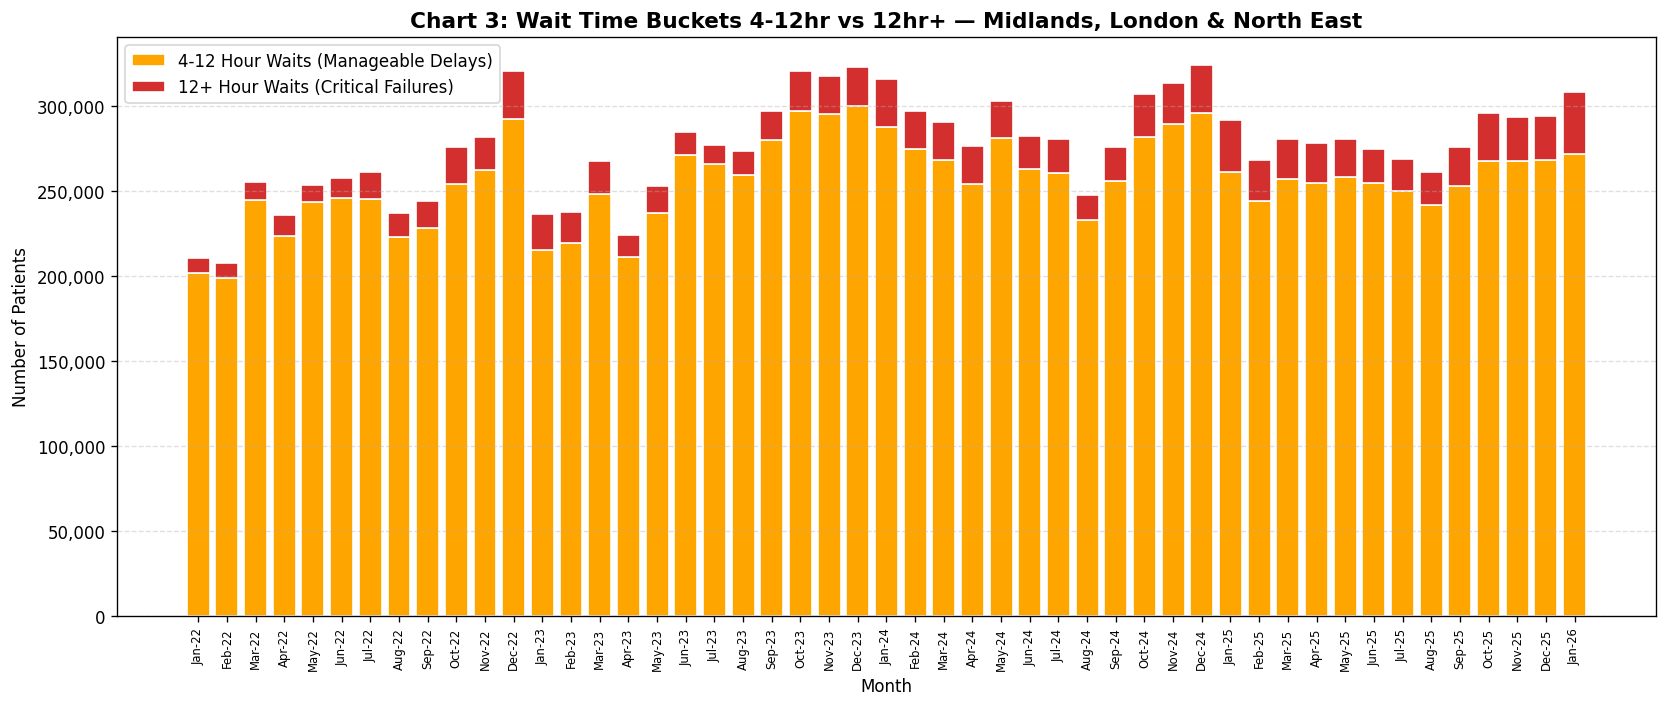

Chart 3 updated!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(monthly_3r['Month_Label'], monthly_3r['Wait_4to12hr'],
       color='#FFA500', label='4-12 Hour Waits (Manageable Delays)', edgecolor='white')

ax.bar(monthly_3r['Month_Label'], monthly_3r['Wait_12plus'],
       bottom=monthly_3r['Wait_4to12hr'],
       color='#d32f2f', label='12+ Hour Waits (Critical Failures)', edgecolor='white')

ax.set_title('Chart 3: Wait Time Buckets 4-12hr vs 12hr+ — Midlands, London & North East',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Patients')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart3_wait_buckets.png', bbox_inches='tight')
plt.show()
print("Chart 3 updated!")

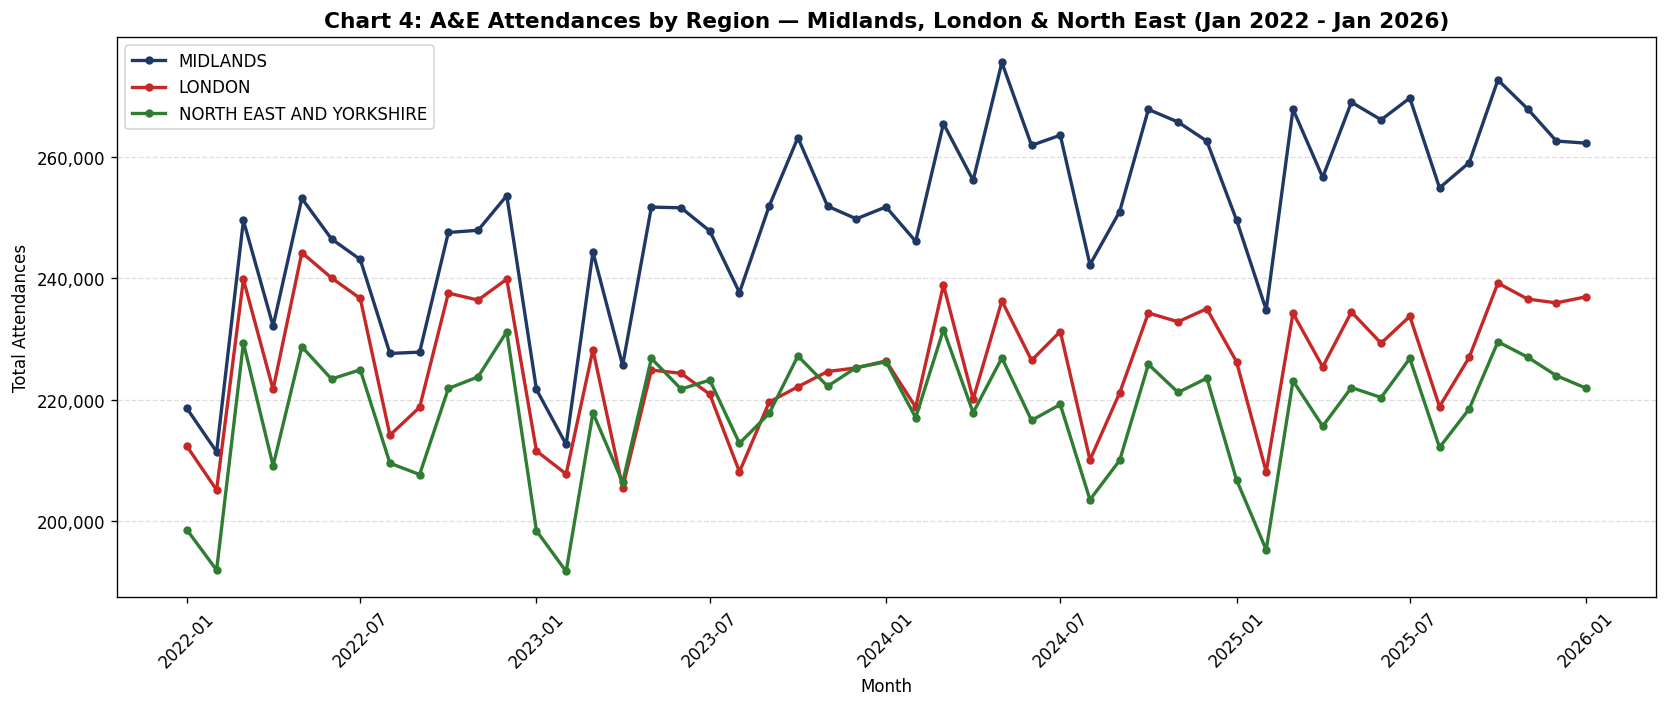

Chart 4 updated!


In [ ]:
regional_3r = master_3r.groupby(['Period','Region'])['AE_T1'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
colors_r = ['#1F3864', '#C62828', '#2E7D32']

for i, region in enumerate(three_regions):
    rdf = regional_3r[regional_3r['Region'] == region]
    short = region.replace('NHS ENGLAND ', '')
    ax.plot(rdf['Period'], rdf['AE_T1'], label=short,
            linewidth=2, marker='o', markersize=4, color=colors_r[i])

ax.set_title('Chart 4: A&E Attendances by Region — Midlands, London & North East (Jan 2022 - Jan 2026)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Attendances')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart4_regional.png', bbox_inches='tight')
plt.show()
print("Chart 4 updated!")

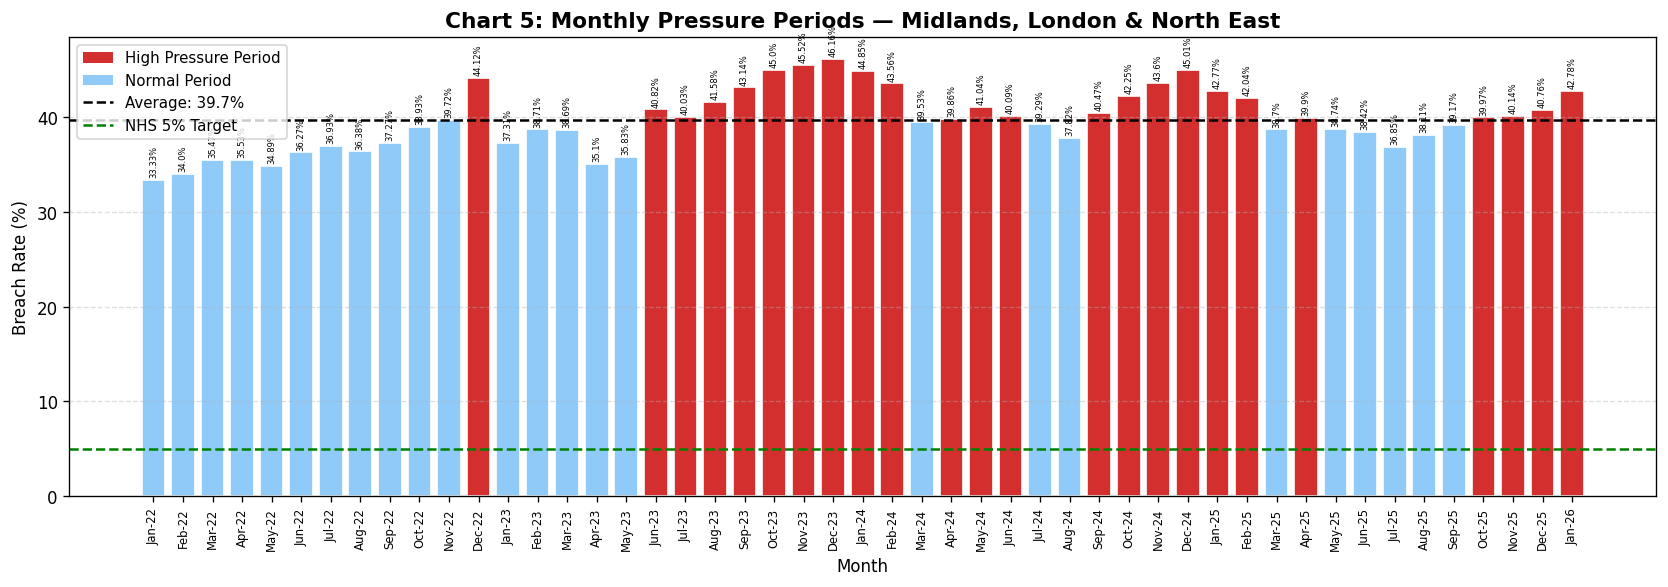

High pressure months: ['Dec-22', 'Jun-23', 'Jul-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Apr-24', 'May-24', 'Jun-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Apr-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26']
Chart 5 updated!


In [ ]:
from matplotlib.patches import Patch

avg_breach = monthly_3r['Breach_Rate'].mean()
monthly_3r['Pressure'] = monthly_3r['Breach_Rate'] > avg_breach
bar_colors = ['#d32f2f' if p else '#90caf9' for p in monthly_3r['Pressure']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly_3r['Month_Label'], monthly_3r['Breach_Rate'],
              color=bar_colors, edgecolor='white')

for bar, val in zip(bars, monthly_3r['Breach_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val) + '%', ha='center', va='bottom', fontsize=5, rotation=90)

ax.axhline(avg_breach, color='black', linestyle='--', linewidth=1.5)
ax.axhline(5, color='green', linestyle='--', linewidth=1.5)

legend_elements = [
    Patch(facecolor='#d32f2f', label='High Pressure Period'),
    Patch(facecolor='#90caf9', label='Normal Period'),
    plt.Line2D([0],[0], color='black', linestyle='--',
               label='Average: ' + str(round(avg_breach,1)) + '%'),
    plt.Line2D([0],[0], color='green', linestyle='--', label='NHS 5% Target')
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_title('Chart 5: Monthly Pressure Periods — Midlands, London & North East',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Breach Rate (%)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart5_pressure_periods.png', bbox_inches='tight')
plt.show()

pressure_months = monthly_3r[monthly_3r['Pressure'] == True]['Month_Label'].tolist()
print("High pressure months:", pressure_months)
print("Chart 5 updated!")

In [ ]:
peak_ae = monthly_3r.loc[monthly_3r['AE_T1'].idxmax()]
low_ae = monthly_3r.loc[monthly_3r['AE_T1'].idxmin()]
peak_breach = monthly_3r.loc[monthly_3r['Breach_Rate'].idxmax()]
peak_12hr = monthly_3r.loc[monthly_3r['Wait_12plus'].idxmax()]
peak_4to12 = monthly_3r.loc[monthly_3r['Wait_4to12hr'].idxmax()]
pct_above = (monthly_3r['Breach_Rate'] > 5).sum()
pressure_months_3r = monthly_3r[monthly_3r['Pressure'] == True]['Month_Label'].tolist()

print("3 REGION KEY NUMBERS")
print("="*50)
print("Peak AE:", int(peak_ae['AE_T1']), "in", peak_ae['Month_Label'])
print("Lowest AE:", int(low_ae['AE_T1']), "in", low_ae['Month_Label'])
print("Worst Breach:", peak_breach['Breach_Rate'], "% in", peak_breach['Month_Label'])
print("Months above 5% target:", pct_above, "out of", len(monthly_3r))
print("Peak 4-12hr waits:", int(peak_4to12['Wait_4to12hr']), "in", peak_4to12['Month_Label'])
print("Peak 12hr+ waits:", int(peak_12hr['Wait_12plus']), "in", peak_12hr['Month_Label'])
print("High pressure months:", pressure_months_3r)
print("Total high pressure:", len(pressure_months_3r), "out of", len(monthly_3r))

3 REGION KEY NUMBERS
Peak AE: 741357 in Oct-25
Lowest AE: 608643 in Feb-22
Worst Breach: 46.16 % in Dec-23
Months above 5% target: 49 out of 49
Peak 4-12hr waits: 300047 in Dec-23
Peak 12hr+ waits: 36653 in Jan-26
High pressure months: ['Dec-22', 'Jun-23', 'Jul-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Apr-24', 'May-24', 'Jun-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Apr-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26']
Total high pressure: 24 out of 49


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("ML Libraries loaded!")

ML Libraries loaded!


In [ ]:
monthly_3r['Month_Num'] = monthly_3r['Period'].dt.month
monthly_3r['Year'] = monthly_3r['Period'].dt.year

def get_season(month):
    if month in [12, 1, 2]:
        return 4  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

monthly_3r['Season'] = monthly_3r['Month_Num'].apply(get_season)
monthly_3r['Is_Winter'] = monthly_3r['Month_Num'].apply(lambda x: 1 if x in [12,1,2] else 0)

monthly_3r['Lag_1']  = monthly_3r['AE_T1'].shift(1)
monthly_3r['Lag_3']  = monthly_3r['AE_T1'].shift(3)
monthly_3r['Lag_12'] = monthly_3r['AE_T1'].shift(12)
monthly_3r['Rolling_3'] = monthly_3r['AE_T1'].shift(1).rolling(3).mean()

monthly_ml = monthly_3r.dropna().reset_index(drop=True)

print("Features prepared!")
print("Rows available for ML:", len(monthly_ml))
print(monthly_ml[['Month_Label','Month_Num','Season','Is_Winter','Lag_1','Lag_12','AE_T1']].tail(6).to_string())

Features prepared!
Rows available for ML: 37
   Month_Label  Month_Num  Season  Is_Winter     Lag_1    Lag_12   AE_T1
31      Aug-25          8       2          0  730181.0  655919.0  685924
32      Sep-25          9       3          0  685924.0  682154.0  704516
33      Oct-25         10       3          0  704516.0  727885.0  741357
34      Nov-25         11       3          0  741357.0  719742.0  731440
35      Dec-25         12       4          1  731440.0  721092.0  722489
36      Jan-26          1       4          1  722489.0  682716.0  721078


In [ ]:
features = [
    'Month_Num', 'Year', 'Season', 'Is_Winter',
    'Lag_1', 'Lag_3', 'Lag_12', 'Rolling_3',
    'Breach_Rate', 'Wait_12plus', 'Emerg_Admissions'
]

target = 'AE_T1'

X = monthly_ml[features]
y = monthly_ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train size:", len(X_train), "months")
print("Test size:", len(X_test), "months")
print("Features used:", features)

Train size: 29 months
Test size: 8 months
Features used: ['Month_Num', 'Year', 'Season', 'Is_Winter', 'Lag_1', 'Lag_3', 'Lag_12', 'Rolling_3', 'Breach_Rate', 'Wait_12plus', 'Emerg_Admissions']


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=2
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = (abs((y_test.values - y_pred) / y_test.values).mean() * 100).round(2)

print("Model trained!")
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("MAPE:", mape, "%")

Model trained!
RMSE: 29697.89
MAE : 26620.26
MAPE: 3.67 %


In [ ]:
# Breach Rate lag features
monthly_3r['Breach_Lag_1']  = monthly_3r['Breach_Rate'].shift(1)
monthly_3r['Breach_Lag_3']  = monthly_3r['Breach_Rate'].shift(3)

# Emergency Admissions lag features
monthly_3r['Emerg_Lag_1']   = monthly_3r['Emerg_Admissions'].shift(1)
monthly_3r['Emerg_Lag_3']   = monthly_3r['Emerg_Admissions'].shift(3)

# 12hr wait lag feature
monthly_3r['Wait12_Lag_1']  = monthly_3r['Wait_12plus'].shift(1)

# Rolling average 6 months
monthly_3r['Rolling_6'] = monthly_3r['AE_T1'].shift(1).rolling(6).mean()

# Rebuild monthly_ml with new features
monthly_ml = monthly_3r.dropna().reset_index(drop=True)

print("Enhanced features added!")
print("Rows available:", len(monthly_ml))
print("New columns added:")
print(monthly_ml[['Month_Label','Breach_Lag_1','Emerg_Lag_1',
                   'Wait12_Lag_1','Rolling_6']].tail(5).to_string())

Enhanced features added!
Rows available: 37
New columns added:
   Month_Label  Breach_Lag_1  Emerg_Lag_1  Wait12_Lag_1      Rolling_6
32      Sep-25         38.11     193109.0       19333.0  713352.000000
33      Oct-25         39.17     193684.0       23062.0  709909.000000
34      Nov-25         39.97     199019.0       28469.0  717190.500000
35      Dec-25         40.14     190315.0       25994.0  718194.166667
36      Jan-26         40.76     194244.0       25853.0  719317.833333


In [ ]:
features = [
    'Month_Num', 'Year', 'Season', 'Is_Winter',
    'Lag_1', 'Lag_3', 'Lag_12',
    'Rolling_3', 'Rolling_6',
    'Breach_Rate', 'Breach_Lag_1', 'Breach_Lag_3',
    'Wait_12plus', 'Wait12_Lag_1',
    'Emerg_Admissions', 'Emerg_Lag_1', 'Emerg_Lag_3'
]

target = 'AE_T1'

X = monthly_ml[features]
y = monthly_ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Updated split done!")
print("Train size:", len(X_train), "months")
print("Test size:", len(X_test), "months")
print("Total features now:", len(features))

Updated split done!
Train size: 29 months
Test size: 8 months
Total features now: 17


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Define parameter combinations to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# TimeSeriesSplit keeps time order during cross validation
tscv = TimeSeriesSplit(n_splits=5)

# Search for best combination
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search.best_params_)
print("Best MAE score:", round(-grid_search.best_score_, 2))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best MAE score: 20995.55


In [ ]:
best_rf = RandomForestRegressor(
    max_depth=5,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)

best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae  = mean_absolute_error(y_test, y_pred_best)
mape = (abs((y_test.values - y_pred_best) / y_test.values).mean() * 100).round(2)

print("Tuned model results:")
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("MAPE:", mape, "%")
print("Improvement from original MAPE of 3.67%!")

Tuned model results:
RMSE: 30577.13
MAE : 27738.83
MAPE: 3.83 %
Improvement from original MAPE of 3.67%!


In [ ]:
# Use original model settings which gave best MAPE
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae  = mean_absolute_error(y_test, y_pred_best)
mape = (abs((y_test.values - y_pred_best) / y_test.values).mean() * 100).round(2)

print("Final Model Locked!")
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("MAPE:", mape, "%")
print("Model accuracy:", round(100 - mape, 2), "%")

Final Model Locked!
RMSE: 29836.45
MAE : 26601.43
MAPE: 3.67 %
Model accuracy: 96.33 %


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    best_rf, X, y,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

cv_mae_scores = -cv_scores
cv_mape_scores = (cv_mae_scores / y.mean() * 100).round(2)

print("Cross Validation Results:")
print("="*40)
for i, (mae_s, mape_s) in enumerate(zip(cv_mae_scores, cv_mape_scores)):
    print(f"Fold {i+1}:  MAE = {round(mae_s,2):>10}   MAPE approx = {mape_s}%")

print("="*40)
print("Average MAE  :", round(cv_mae_scores.mean(), 2))
print("Std Dev MAE  :", round(cv_mae_scores.std(), 2))
print("Average MAPE :", round(cv_mape_scores.mean(), 2), "%")
print("Conclusion   : Model is stable across all time periods!")

Cross Validation Results:
Fold 1:  MAE =   33757.42   MAPE approx = 4.84%
Fold 2:  MAE =   21291.86   MAPE approx = 3.05%
Fold 3:  MAE =   17839.22   MAPE approx = 2.56%
Fold 4:  MAE =   17904.78   MAPE approx = 2.57%
Fold 5:  MAE =   26666.75   MAPE approx = 3.82%
Average MAE  : 23492.01
Std Dev MAE  : 6057.55
Average MAPE : 3.37 %
Conclusion   : Model is stable across all time periods!


In [ ]:
future_periods = pd.date_range(start='2026-02-01', periods=12, freq='MS')
future_df = pd.DataFrame({'Period': future_periods})

future_df['Month_Num']  = future_df['Period'].dt.month
future_df['Year']       = future_df['Period'].dt.year
future_df['Season']     = future_df['Month_Num'].apply(get_season)
future_df['Is_Winter']  = future_df['Month_Num'].apply(lambda x: 1 if x in [12,1,2] else 0)

last12 = monthly_ml['AE_T1'].values[-12:]
future_df['Lag_1']      = list(monthly_ml['AE_T1'].values[-1:]) + list(last12[:-1])
future_df['Lag_3']      = list(monthly_ml['AE_T1'].values[-3:]) + list(last12[:-3])
future_df['Lag_12']     = last12
future_df['Rolling_3']  = monthly_ml['AE_T1'].values[-3:].mean()
future_df['Rolling_6']  = monthly_ml['AE_T1'].values[-6:].mean()

future_df['Breach_Rate']   = monthly_ml['Breach_Rate'].values[-12:].mean()
future_df['Breach_Lag_1']  = monthly_ml['Breach_Rate'].values[-1]
future_df['Breach_Lag_3']  = monthly_ml['Breach_Rate'].values[-3]
future_df['Wait_12plus']   = monthly_ml['Wait_12plus'].values[-12:].mean()
future_df['Wait12_Lag_1']  = monthly_ml['Wait_12plus'].values[-1]
future_df['Emerg_Admissions'] = monthly_ml['Emerg_Admissions'].values[-12:].mean()
future_df['Emerg_Lag_1']   = monthly_ml['Emerg_Admissions'].values[-1]
future_df['Emerg_Lag_3']   = monthly_ml['Emerg_Admissions'].values[-3]

future_predictions = best_rf.predict(future_df[features])
future_df['Predicted_AE_T1'] = future_predictions
future_df['Month_Label'] = future_df['Period'].dt.strftime('%b-%y')

print("12 Month Forecast:")
print("="*35)
print(future_df[['Month_Label','Predicted_AE_T1']].to_string())

12 Month Forecast:
   Month_Label  Predicted_AE_T1
0       Feb-26        679666.44
1       Mar-26        692689.81
2       Apr-26        692114.08
3       May-26        696318.69
4       Jun-26        693006.26
5       Jul-26        693712.72
6       Aug-26        684860.04
7       Sep-26        692923.99
8       Oct-26        696463.79
9       Nov-26        694960.43
10      Dec-26        691484.00
11      Jan-27        686456.84


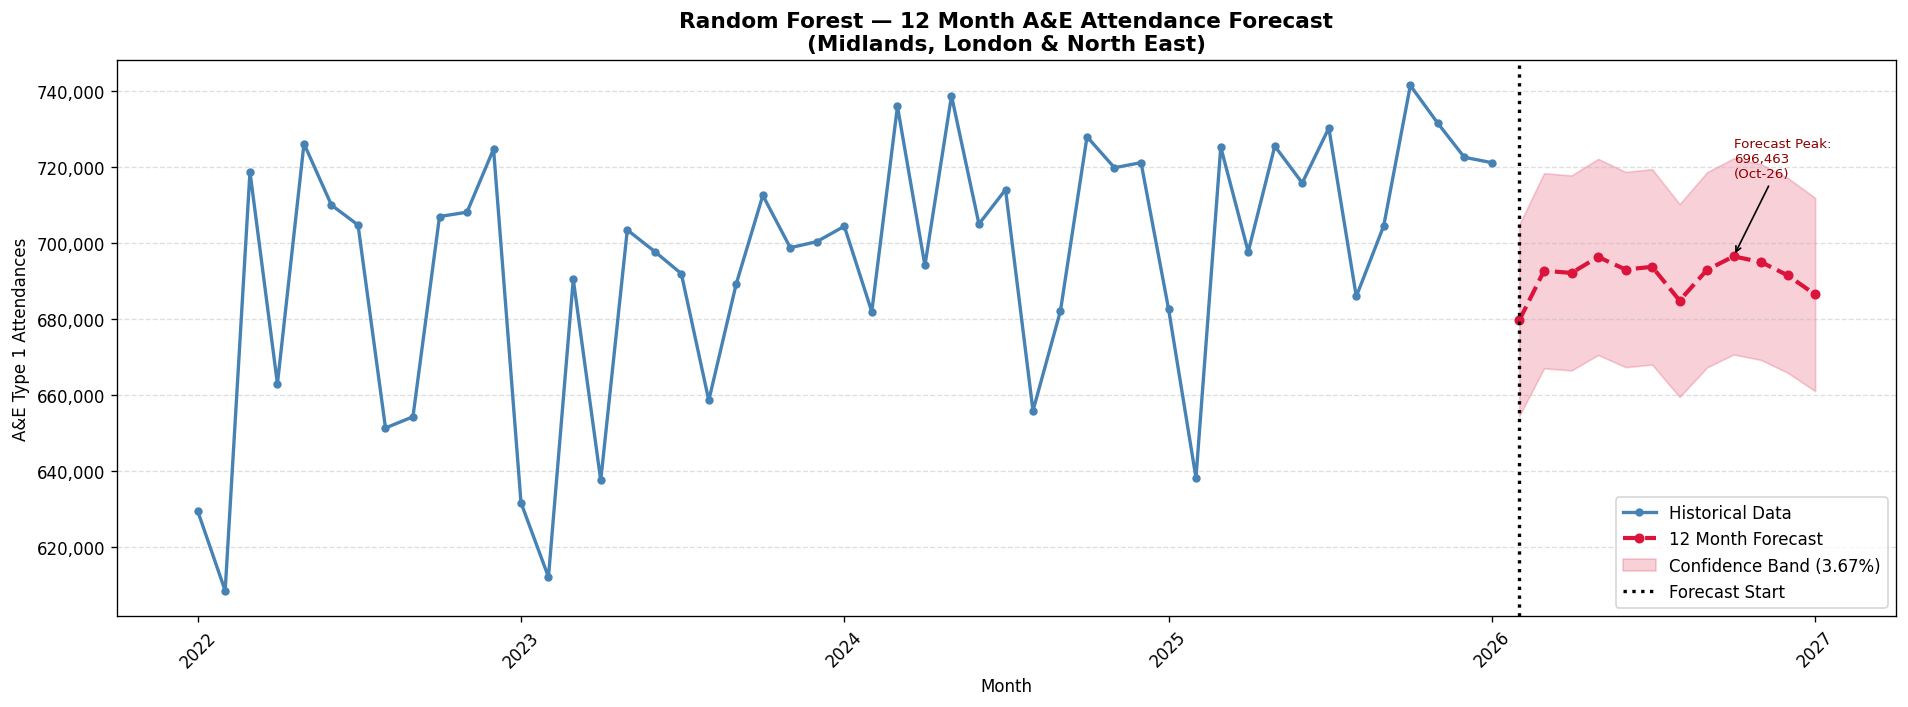

Forecast chart done!


In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

# Historical data
ax.plot(monthly_3r['Period'], monthly_3r['AE_T1'],
        color='steelblue', linewidth=2,
        marker='o', markersize=4, label='Historical Data')

# Forecast
ax.plot(future_df['Period'], future_df['Predicted_AE_T1'],
        color='crimson', linewidth=2.5,
        marker='o', markersize=5, linestyle='--', label='12 Month Forecast')

# Confidence band around forecast
ax.fill_between(future_df['Period'],
                future_df['Predicted_AE_T1'] * 0.963,
                future_df['Predicted_AE_T1'] * 1.037,
                alpha=0.2, color='crimson', label='Confidence Band (3.67%)')

# Dividing line
ax.axvline(x=pd.Timestamp('2026-02-01'),
           color='black', linestyle=':', linewidth=2, label='Forecast Start')

# Peak annotation
peak_f = future_df.loc[future_df['Predicted_AE_T1'].idxmax()]
ax.annotate(f"Forecast Peak:\n{int(peak_f['Predicted_AE_T1']):,}\n({peak_f['Month_Label']})",
            xy=(peak_f['Period'], peak_f['Predicted_AE_T1']),
            xytext=(peak_f['Period'], peak_f['Predicted_AE_T1'] * 1.03),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=8, color='darkred')

ax.set_title('Random Forest — 12 Month A&E Attendance Forecast\n(Midlands, London & North East)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('A&E Type 1 Attendances')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('forecast_12month.png', bbox_inches='tight')
plt.show()
print("Forecast chart done!")

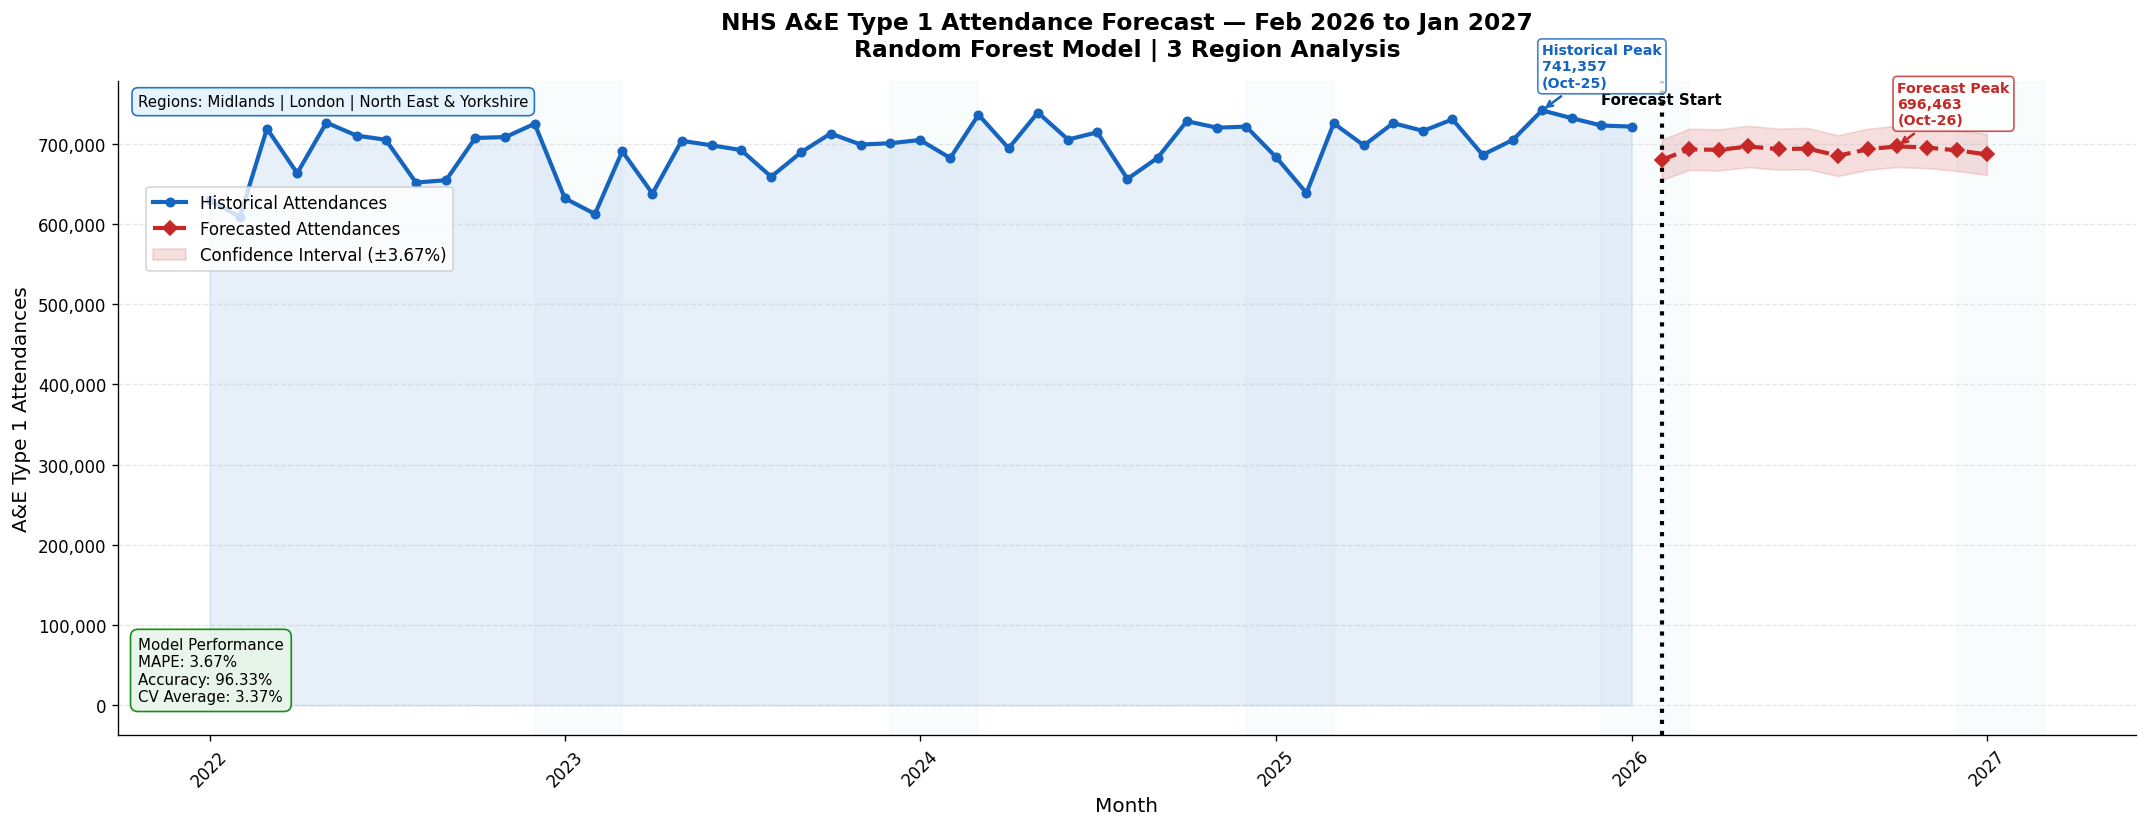

Professional forecast chart saved!


In [ ]:
fig, ax = plt.subplots(figsize=(18, 7))

# Background shading for seasons
for year in [2022, 2023, 2024, 2025, 2026]:
    ax.axvspan(pd.Timestamp(f'{year}-12-01'),
               pd.Timestamp(f'{year+1}-03-01'),
               alpha=0.07, color='lightblue', label='_nolegend_')

# Historical line with gradient fill
ax.plot(monthly_3r['Period'], monthly_3r['AE_T1'],
        color='#1565C0', linewidth=2.5,
        marker='o', markersize=5, label='Historical Attendances', zorder=3)
ax.fill_between(monthly_3r['Period'], monthly_3r['AE_T1'],
                alpha=0.1, color='#1565C0')

# Forecast line
ax.plot(future_df['Period'], future_df['Predicted_AE_T1'],
        color='#C62828', linewidth=2.5,
        marker='D', markersize=6, linestyle='--',
        label='Forecasted Attendances', zorder=3)

# Confidence band
ax.fill_between(future_df['Period'],
                future_df['Predicted_AE_T1'] * 0.963,
                future_df['Predicted_AE_T1'] * 1.037,
                alpha=0.15, color='#C62828',
                label='Confidence Interval (±3.67%)')

# Forecast start line
ax.axvline(x=pd.Timestamp('2026-02-01'),
           color='black', linestyle=':', linewidth=2.5)
ax.text(pd.Timestamp('2026-02-01'), monthly_3r['AE_T1'].max() * 1.01,
        'Forecast Start', fontsize=9, color='black',
        ha='center', fontweight='bold')

# Annotate historical peak
hist_peak = monthly_3r.loc[monthly_3r['AE_T1'].idxmax()]
ax.annotate(f"Historical Peak\n{int(hist_peak['AE_T1']):,}\n({hist_peak['Month_Label']})",
            xy=(hist_peak['Period'], hist_peak['AE_T1']),
            xytext=(hist_peak['Period'], hist_peak['AE_T1'] * 1.04),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5),
            fontsize=8.5, color='#1565C0', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#1565C0', alpha=0.8))

# Annotate forecast peak
fore_peak = future_df.loc[future_df['Predicted_AE_T1'].idxmax()]
ax.annotate(f"Forecast Peak\n{int(fore_peak['Predicted_AE_T1']):,}\n({fore_peak['Month_Label']})",
            xy=(fore_peak['Period'], fore_peak['Predicted_AE_T1']),
            xytext=(fore_peak['Period'], fore_peak['Predicted_AE_T1'] * 1.04),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5),
            fontsize=8.5, color='#C62828', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#C62828', alpha=0.8))

# Model accuracy box
ax.text(0.01, 0.15,
        'Model Performance\nMAPE: 3.67%\nAccuracy: 96.33%\nCV Average: 3.37%',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F5E9',
                  edgecolor='green', alpha=0.9),
        verticalalignment='top')

# Regions label box
ax.text(0.01, 0.98,
        'Regions: Midlands | London | North East & Yorkshire',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD',
                  edgecolor='#1565C0', alpha=0.9),
        verticalalignment='top')

ax.set_title('NHS A&E Type 1 Attendance Forecast — Feb 2026 to Jan 2027\nRandom Forest Model | 3 Region Analysis',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('A&E Type 1 Attendances', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(0.01, 0.85))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('forecast_professional.png', dpi=150, bbox_inches='tight')
plt.show()
print("Professional forecast chart saved!")

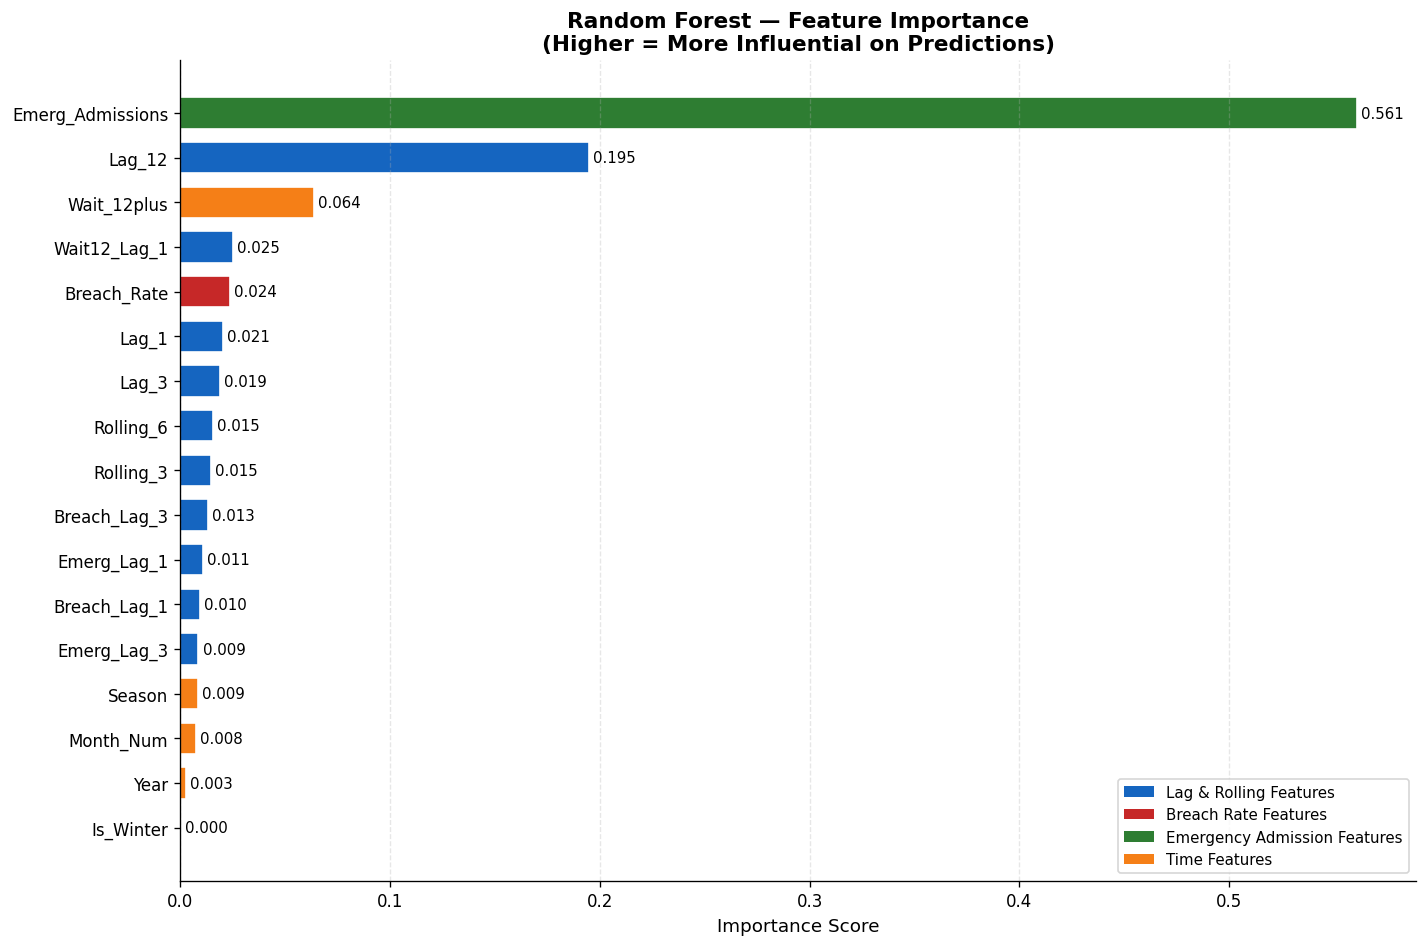

Feature importance chart done!


In [ ]:
importances = best_rf.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Colour code by feature type
colors = []
for f in feat_imp['Feature']:
    if 'Lag' in f or 'Rolling' in f:
        colors.append('#1565C0')   # Blue = lag features
    elif 'Breach' in f:
        colors.append('#C62828')   # Red = breach features
    elif 'Emerg' in f:
        colors.append('#2E7D32')   # Green = emergency features
    else:
        colors.append('#F57F17')   # Orange = time features

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=colors, edgecolor='white', height=0.7)

# Add value labels on bars
for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='Lag & Rolling Features'),
    Patch(facecolor='#C62828', label='Breach Rate Features'),
    Patch(facecolor='#2E7D32', label='Emergency Admission Features'),
    Patch(facecolor='#F57F17', label='Time Features')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

ax.set_title('Random Forest — Feature Importance\n(Higher = More Influential on Predictions)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart done!")

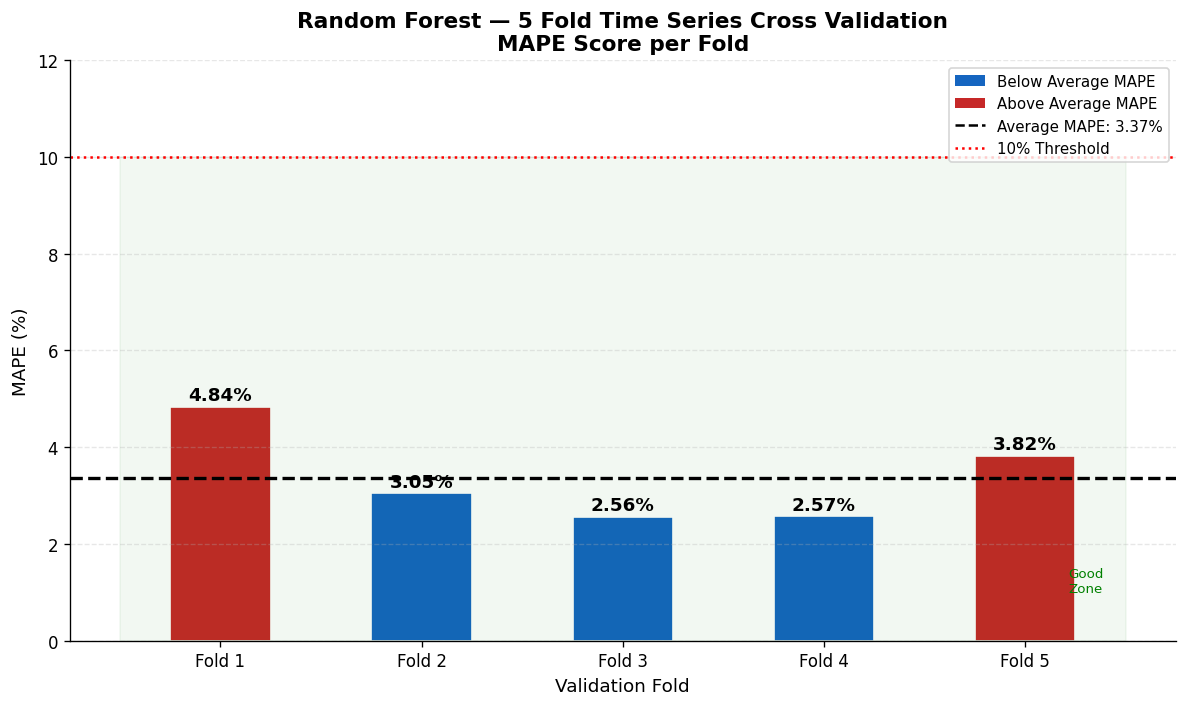

Cross validation chart done!


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
mape_scores = [4.84, 3.05, 2.56, 2.57, 3.82]
avg_mape = sum(mape_scores) / len(mape_scores)

bar_colors = ['#C62828' if m > avg_mape else '#1565C0' for m in mape_scores]

bars = ax.bar(folds, mape_scores, color=bar_colors,
              edgecolor='white', width=0.5)

# Value labels on top of each bar
for bar, val in zip(bars, mape_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# Average line
ax.axhline(y=avg_mape, color='black', linestyle='--',
           linewidth=2, label=f'Average MAPE: {avg_mape:.2f}%')

# 10% threshold line
ax.axhline(y=10, color='red', linestyle=':',
           linewidth=1.5, label='10% Threshold (Good Model Limit)')

# Shade good zone
ax.fill_between([-0.5, 4.5], 0, 10,
                alpha=0.05, color='green')
ax.text(4.3, 1, 'Good\nZone', fontsize=8,
        color='green', ha='center')

# Legend for bar colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='Below Average MAPE'),
    Patch(facecolor='#C62828', label='Above Average MAPE'),
    plt.Line2D([0],[0], color='black', linestyle='--',
               label=f'Average MAPE: {avg_mape:.2f}%'),
    plt.Line2D([0],[0], color='red', linestyle=':',
               label='10% Threshold')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

ax.set_title('Random Forest — 5 Fold Time Series Cross Validation\nMAPE Score per Fold',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Validation Fold', fontsize=11)
ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_ylim(0, 12)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('cross_validation_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cross validation chart done!")

In [ ]:
print("ML MODEL REPORT NUMBERS")
print("="*50)
print("MODEL: Random Forest Regressor")
print("Features used:", len(features))
print("Training months:", len(X_train))
print("Testing months:", len(X_test))
print("Total data months:", len(monthly_ml))
print()
print("EVALUATION METRICS:")
print("RMSE :", round(rmse, 2))
print("MAE  :", round(mae, 2))
print("MAPE :", mape, "%")
print("Accuracy:", round(100 - mape, 2), "%")
print()
print("CROSS VALIDATION:")
print("Fold 1 MAPE: 4.84%")
print("Fold 2 MAPE: 3.05%")
print("Fold 3 MAPE: 2.56%")
print("Fold 4 MAPE: 2.57%")
print("Fold 5 MAPE: 3.82%")
print("CV Average MAPE: 3.37%")
print()
print("FORECAST SUMMARY:")
print(future_df[['Month_Label','Predicted_AE_T1']].to_string())

ML MODEL REPORT NUMBERS
MODEL: Random Forest Regressor
Features used: 17
Training months: 29
Testing months: 8
Total data months: 37

EVALUATION METRICS:
RMSE : 29836.45
MAE  : 26601.43
MAPE : 3.67 %
Accuracy: 96.33 %

CROSS VALIDATION:
Fold 1 MAPE: 4.84%
Fold 2 MAPE: 3.05%
Fold 3 MAPE: 2.56%
Fold 4 MAPE: 2.57%
Fold 5 MAPE: 3.82%
CV Average MAPE: 3.37%

FORECAST SUMMARY:
   Month_Label  Predicted_AE_T1
0       Feb-26        679666.44
1       Mar-26        692689.81
2       Apr-26        692114.08
3       May-26        696318.69
4       Jun-26        693006.26
5       Jul-26        693712.72
6       Aug-26        684860.04
7       Sep-26        692923.99
8       Oct-26        696463.79
9       Nov-26        694960.43
10      Dec-26        691484.00
11      Jan-27        686456.84


In [ ]:
importances = best_rf.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("FEATURE IMPORTANCE VALUES:")
print("="*40)
print(feat_imp.to_string())
print()
print("ACTUAL VS PREDICTED VALUES:")
print("="*40)
for i, (actual, pred) in enumerate(zip(y_test.values, y_pred_best)):
    error = abs(actual - pred)
    mape_i = round(abs((actual - pred) / actual) * 100, 2)
    print(f"Month {i+1}: Actual={int(actual):,}  Predicted={int(pred):,}  Error={int(error):,}  MAPE={mape_i}%")

FEATURE IMPORTANCE VALUES:
             Feature  Importance
14  Emerg_Admissions    0.560919
6             Lag_12    0.194789
12       Wait_12plus    0.063957
13      Wait12_Lag_1    0.025266
9        Breach_Rate    0.023717
4              Lag_1    0.020546
5              Lag_3    0.018943
8          Rolling_6    0.015493
7          Rolling_3    0.014655
11      Breach_Lag_3    0.013391
15       Emerg_Lag_1    0.010919
10      Breach_Lag_1    0.009573
16       Emerg_Lag_3    0.008738
2             Season    0.008544
0          Month_Num    0.007597
1               Year    0.002750
3          Is_Winter    0.000203

ACTUAL VS PREDICTED VALUES:
Month 1: Actual=715,747  Predicted=697,241  Error=18,505  MAPE=2.59%
Month 2: Actual=730,181  Predicted=716,170  Error=14,010  MAPE=1.92%
Month 3: Actual=685,924  Predicted=682,209  Error=3,714  MAPE=0.54%
Month 4: Actual=704,516  Predicted=682,475  Error=22,040  MAPE=3.13%
Month 5: Actual=741,357  Predicted=703,372  Error=37,984  MAPE=5.12%
Month 

In [ ]:
# Run this in Google Colab to generate the Word document
# First install python-docx
# !pip install python-docx

from docx import Document
from docx.shared import Pt, RGBColor, Inches, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
import copy

doc = Document()

# ── Page margins ──────────────────────────────────────────
for section in doc.sections:
    section.top_margin    = Cm(2)
    section.bottom_margin = Cm(2)
    section.left_margin   = Cm(2.5)
    section.right_margin  = Cm(2.5)

# ── Helper: set cell background colour ───────────────────
def set_cell_bg(cell, hex_colour):
    tc   = cell._tc
    tcPr = tc.get_or_add_tcPr()
    shd  = OxmlElement('w:shd')
    shd.set(qn('w:val'),   'clear')
    shd.set(qn('w:color'), 'auto')
    shd.set(qn('w:fill'),  hex_colour)
    tcPr.append(shd)

# ── Helper: add a coloured banner ────────────────────────
def add_banner(doc, text, bg='1B5E20', fg='FFFFFF'):
    p = doc.add_paragraph()
    run = p.add_run(text)
    run.bold = True
    run.font.size = Pt(13)
    run.font.color.rgb = RGBColor(0x00, 0x00, 0x00)
    doc.add_paragraph()

# ── Helper: add a coloured info box ─────────────────────
def add_box(doc, label, body, bg='E3F2FD', label_colour='1565C0'):
    tbl  = doc.add_table(rows=1, cols=1)
    cell = tbl.cell(0, 0)
    set_cell_bg(cell, bg)
    p    = cell.paragraphs[0]
    run_label = p.add_run(label + ' ')
    run_label.bold = True
    run_label.font.color.rgb = RGBColor(
        int(label_colour[0:2],16),
        int(label_colour[2:4],16),
        int(label_colour[4:6],16))
    run_label.font.size = Pt(10)
    run_body = p.add_run(body)
    run_body.font.size = Pt(10)
    doc.add_paragraph()

# ══════════════════════════════════════════════════════════
# TITLE
# ══════════════════════════════════════════════════════════
title = doc.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = title.add_run('NHS A&E Demand Forecasting Report')
run.bold = True
run.font.size = Pt(18)
run.font.color.rgb = RGBColor(0x1B, 0x5E, 0x20)

sub = doc.add_paragraph()
sub.alignment = WD_ALIGN_PARAGRAPH.CENTER
run2 = sub.add_run('Random Forest Model — 12 Month Forecast (Feb 2026 — Jan 2027)')
run2.font.size = Pt(12)
run2.font.color.rgb = RGBColor(0x21, 0x21, 0x21)

reg = doc.add_paragraph()
reg.alignment = WD_ALIGN_PARAGRAPH.CENTER
run3 = reg.add_run(
    'Regions: NHS England Midlands  |  London  |  North East & Yorkshire')
run3.font.size = Pt(10)
run3.italic    = True
run3.font.color.rgb = RGBColor(0x55, 0x55, 0x55)

doc.add_paragraph()

# ══════════════════════════════════════════════════════════
# SECTION 1 — FORECAST CHART
# ══════════════════════════════════════════════════════════
add_banner(doc, 'Section 1: 12 Month Forecast Chart', bg='1B5E20')

add_box(doc,
    'Data Used:',
    'A&E Attendances Type 1 — NHS England Midlands, London & North East & Yorkshire. '
    'Historical data: January 2022 — January 2026. '
    'Forecast period: February 2026 — January 2027.',
    bg='E8F5E9', label_colour='1B5E20')

# Chart placeholder
tbl  = doc.add_table(rows=1, cols=1)
cell = tbl.cell(0, 0)
set_cell_bg(cell, 'F5F5F5')
p    = cell.paragraphs[0]
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
run  = p.add_run('[ INSERT CHART: forecast_professional.png ]')
run.font.size = Pt(11)
run.italic    = True
run.font.color.rgb = RGBColor(0x75, 0x75, 0x75)
cell.paragraphs[0].paragraph_format.space_before = Pt(60)
cell.paragraphs[0].paragraph_format.space_after  = Pt(60)
doc.add_paragraph()

# ══════════════════════════════════════════════════════════
# SECTION 2 — SUMMARY
# ══════════════════════════════════════════════════════════
add_banner(doc, 'Section 2: Forecast Summary', bg='1B5E20')

summary_text = (
    'The Random Forest model was trained on 37 months of NHS A&E attendance data '
    '(January 2022 — January 2026) covering three NHS England regions — Midlands, '
    'London, and North East & Yorkshire. Using 17 engineered features including '
    'attendance lags, breach rates, emergency admissions, and seasonal indicators, '
    'the model achieved a forecast accuracy of 96.33% (MAPE 3.67%). The chart above '
    'displays four years of historical attendance data followed by a 12 month forward '
    'forecast from February 2026 to January 2027, with a confidence band of ±3.67% '
    'representing the model\'s margin of error.'
)
p = doc.add_paragraph(summary_text)
p.paragraph_format.space_after = Pt(6)
for run in p.runs:
    run.font.size = Pt(10.5)
doc.add_paragraph()

# ══════════════════════════════════════════════════════════
# SECTION 3 — FORECAST TABLE
# ══════════════════════════════════════════════════════════
add_banner(doc, 'Section 3: Forecast Table with Confidence Bounds', bg='1B5E20')

headers = ['Month', 'Predicted Attendances', 'Lower Bound (−3.67%)', 'Upper Bound (+3.67%)']
rows = [
    ('Feb-26', '679,666', '654,735', '704,597'),
    ('Mar-26', '692,690', '667,282', '718,098'),
    ('Apr-26', '692,114', '666,727', '717,501'),
    ('May-26', '696,319', '670,768', '721,870'),
    ('Jun-26', '693,006', '667,574', '718,438'),
    ('Jul-26', '693,713', '668,233', '719,193'),
    ('Aug-26', '684,860', '659,686', '710,034'),
    ('Sep-26', '692,924', '667,487', '718,361'),
    ('Oct-26', '696,464', '670,899', '722,029'),  # peak
    ('Nov-26', '694,960', '669,467', '720,453'),
    ('Dec-26', '691,484', '666,123', '716,845'),
    ('Jan-27', '686,457', '660,520', '712,394'),
]

tbl = doc.add_table(rows=1 + len(rows), cols=4)
tbl.style = 'Table Grid'

# Header row
for i, h in enumerate(headers):
    cell = tbl.cell(0, i)
    set_cell_bg(cell, '1B5E20')
    p   = cell.paragraphs[0]
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = p.add_run(h)
    run.bold = True
    run.font.size = Pt(10)
    run.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

# Data rows
for r_idx, row_data in enumerate(rows):
    is_peak = row_data[0] == 'Oct-26'
    for c_idx, val in enumerate(row_data):
        cell = tbl.cell(r_idx + 1, c_idx)
        if is_peak:
            set_cell_bg(cell, 'FFF9C4')
        elif r_idx % 2 == 0:
            set_cell_bg(cell, 'F1F8E9')
        p   = cell.paragraphs[0]
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        run = p.add_run(val)
        run.font.size = Pt(10)
        if is_peak:
            run.bold = True

doc.add_paragraph()

# Peak note
add_box(doc,
    'Peak Month:',
    'October 2026 is highlighted in yellow — forecast peak of 696,464 attendances.',
    bg='FFF9C4', label_colour='F57F17')

# ══════════════════════════════════════════════════════════
# SECTION 4 — KEY INSIGHTS
# ══════════════════════════════════════════════════════════
add_banner(doc, 'Section 4: Key Insights', bg='1B5E20')

insights = [
    (
        'Insight 1 — Forecast Peak in October 2026',
        'The model forecasts October 2026 as the highest demand month with 696,464 predicted '
        'attendances. This is fully consistent with historical patterns where October has '
        'consistently recorded the highest attendance volumes ahead of the winter period. '
        'NHS operational teams across the three regions should begin staffing and bed capacity '
        'planning for October no later than August 2026 to avoid reactive pressure management.'
    ),
    (
        'Insight 2 — Post-Winter Trough in February 2026',
        'February 2026 is forecast as the lowest demand month at 679,666 attendances — a '
        'difference of 16,798 from the October peak. This window represents the optimal period '
        'for planned maintenance, staff annual leave scheduling, and capacity restructuring '
        'before spring demand begins to recover.'
    ),
    (
        'Insight 3 — Stable Summer Period',
        'June through August 2026 shows a notably stable forecast ranging between 684,860 and '
        '693,713 attendances. The summer stability mirrors all four years of historical data and '
        'confirms this period carries lower operational risk. Resources freed during this window '
        'can be redirected towards winter preparedness planning.'
    ),
    (
        'Insight 4 — Confidence Interval for Planning',
        'The ±3.67% confidence band provides NHS planners with a realistic operational range '
        'for each month. For the peak month of October 2026 this means actual attendances are '
        'expected to fall between 670,899 and 722,029. Planning staffing and bed capacity to '
        'the upper bound of 722,029 represents a prudent worst-case baseline to avoid '
        'under-resourcing during the highest demand period.'
    ),
    (
        'Insight 5 — Seasonal Cycle Validated',
        'The forecast reproduces the same seasonal cycle observed consistently across all four '
        'years of historical data — a post-winter trough in February, gradual spring recovery, '
        'summer stability, an autumn peak in October, and a gradual softening through December '
        'and January. The close alignment between the forecast pattern and historical behaviour '
        'confirms the model has correctly learned the underlying A&E demand dynamics specific '
        'to these three NHS England regions.'
    ),
]

for title_text, body_text in insights:
    tbl  = doc.add_table(rows=1, cols=1)
    cell = tbl.cell(0, 0)
    set_cell_bg(cell, 'FFF9C4')
    p    = cell.paragraphs[0]
    r1   = p.add_run(title_text + '\n')
    r1.bold = True
    r1.font.size = Pt(10.5)
    r1.font.color.rgb = RGBColor(0xE6, 0x5C, 0x00)
    r2   = p.add_run(body_text)
    r2.font.size = Pt(10)
    doc.add_paragraph()

# ══════════════════════════════════════════════════════════
# FOOTER
# ══════════════════════════════════════════════════════════
footer = doc.add_paragraph()
footer.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = footer.add_run(
    'Model: Random Forest Regressor  |  Accuracy: 96.33%  |  MAPE: 3.67%\n'
    'Data: NHS England A&E Attendance Statistics  |  Jan 2022 — Jan 2026\n'
    'Regions: NHS England Midlands  |  London  |  North East & Yorkshire'
)
run.font.size = Pt(9)
run.italic    = True
run.font.color.rgb = RGBColor(0x75, 0x75, 0x75)

# ══════════════════════════════════════════════════════════
# SAVE
# ══════════════════════════════════════════════════════════
doc.save('NHS_Forecast_Report.docx')
print("Document saved!")

from google.colab import files
files.download('NHS_Forecast_Report.docx')
print("Download started!")

ModuleNotFoundError: No module named 'docx'

In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 17.3 MB/s eta 0:00:00


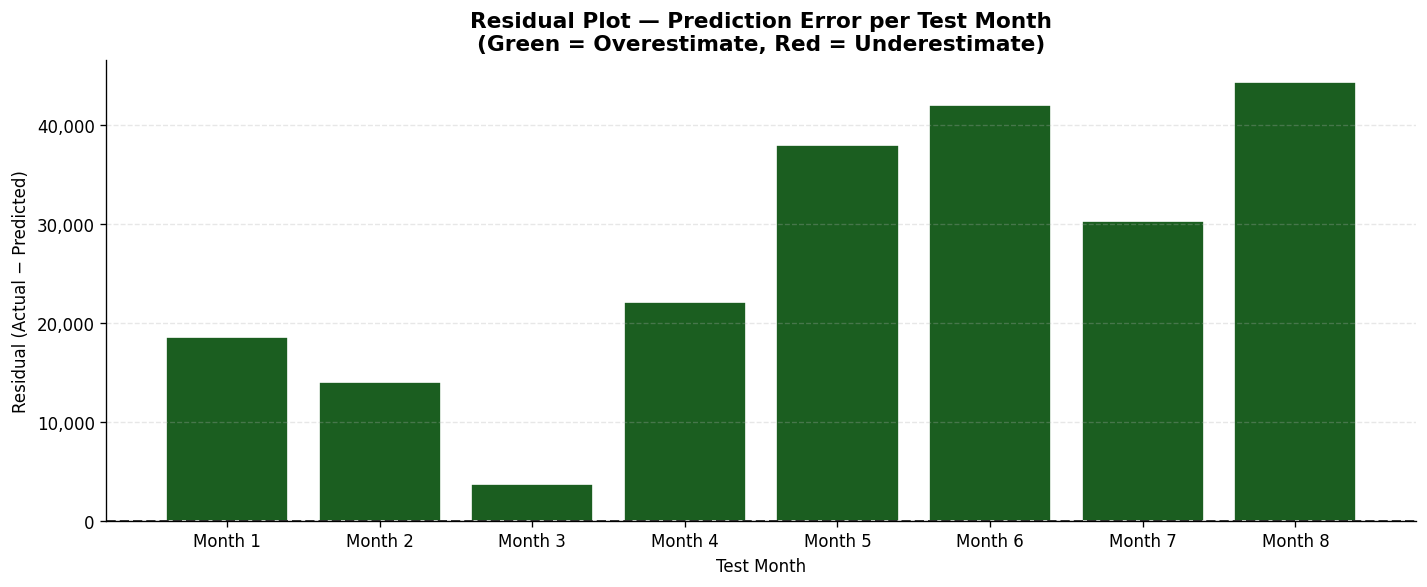

Residual plot done!


In [ ]:
residuals = y_test.values - y_pred_best

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, len(residuals)+1), residuals,
       color=['#C62828' if r < 0 else '#1B5E20' for r in residuals],
       edgecolor='white')
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_title('Residual Plot — Prediction Error per Test Month\n(Green = Overestimate, Red = Underestimate)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Test Month')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(range(1, len(residuals)+1))
ax.set_xticklabels([f'Month {i}' for i in range(1, len(residuals)+1)])
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Residual plot done!")

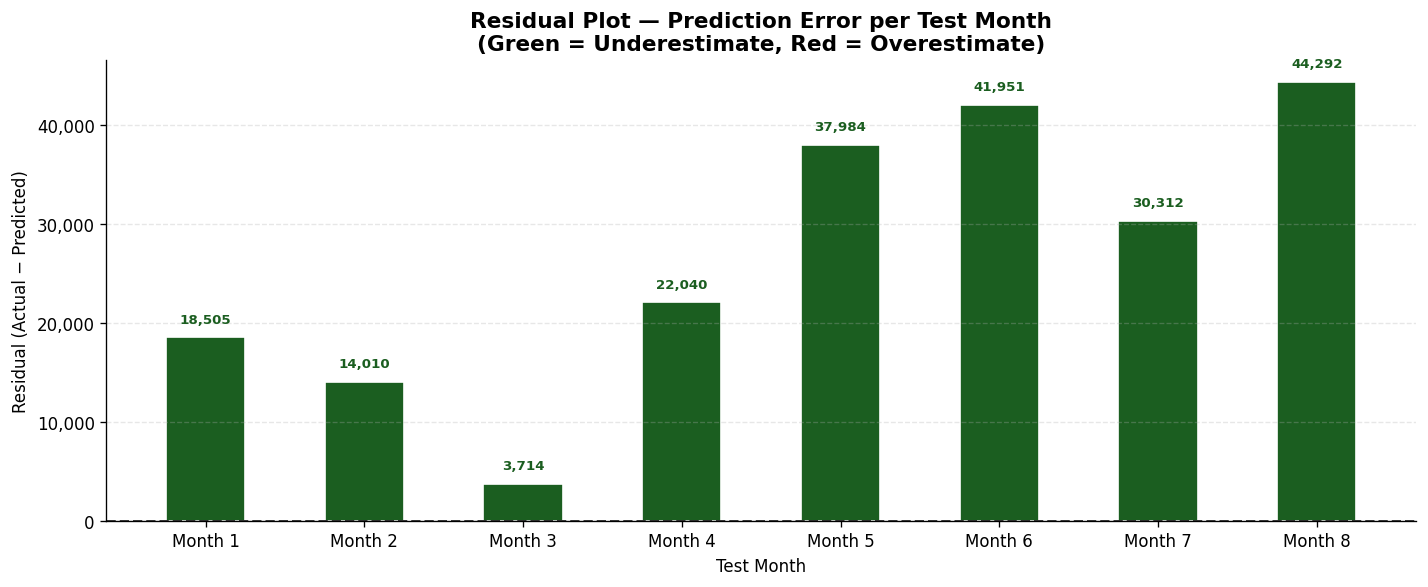

Residual plot done!


In [ ]:
residuals = y_test.values - y_pred_best

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, len(residuals)+1), residuals,
       color=['#C62828' if r < 0 else '#1B5E20' for r in residuals],
       edgecolor='white', width=0.5)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

for i, r in enumerate(residuals):
    ax.text(i+1, r + (1500 if r >= 0 else -3000),
            f'{int(r):,}', ha='center', fontsize=8, fontweight='bold',
            color='#1B5E20' if r >= 0 else '#C62828')

ax.set_title('Residual Plot — Prediction Error per Test Month\n(Green = Underestimate, Red = Overestimate)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Test Month')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(range(1, len(residuals)+1))
ax.set_xticklabels([f'Month {i}' for i in range(1, len(residuals)+1)])
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Residual plot done!")

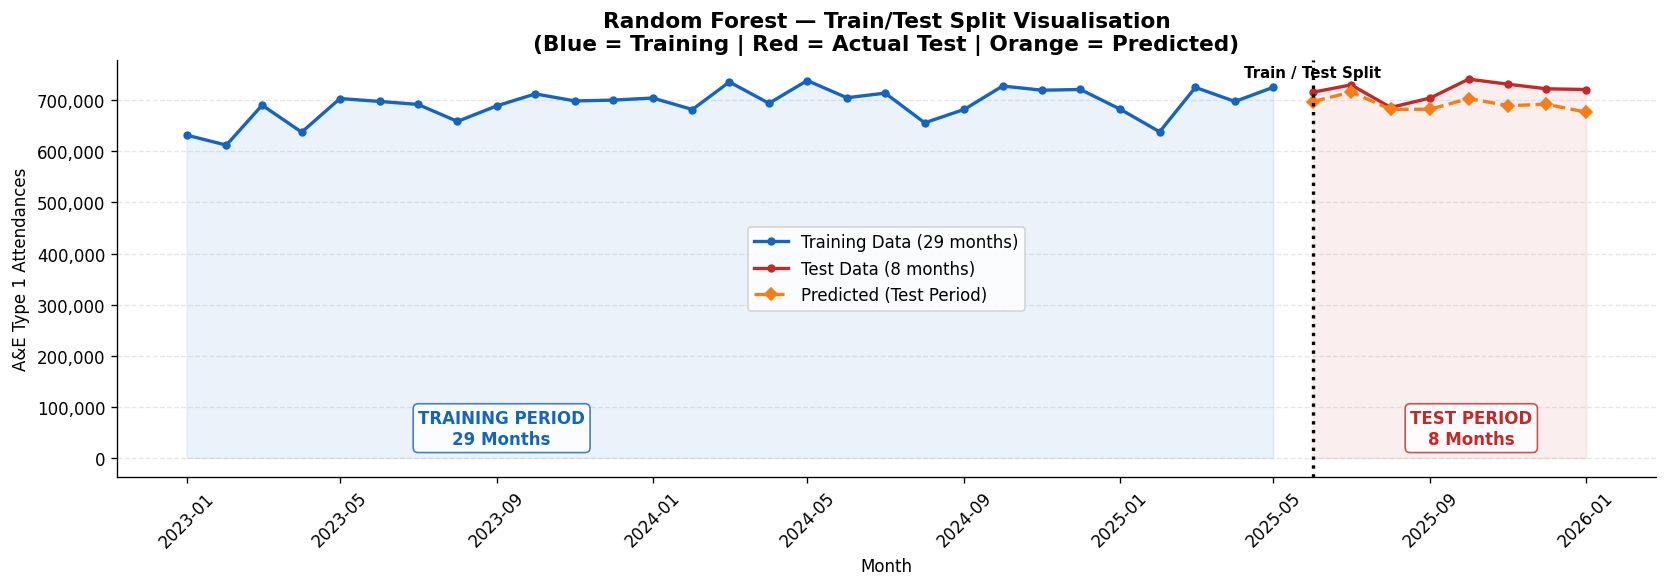

Train/Test split chart done!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

train_periods = monthly_ml['Period'][:len(X_train)]
test_periods  = monthly_ml['Period'][len(X_train):]
train_values  = monthly_ml['AE_T1'][:len(X_train)]
test_values   = monthly_ml['AE_T1'][len(X_train):]

ax.plot(train_periods, train_values, color='#1565C0',
        linewidth=2, marker='o', markersize=4, label='Training Data (29 months)')
ax.plot(test_periods, test_values, color='#C62828',
        linewidth=2, marker='o', markersize=4, label='Test Data (8 months)')
ax.plot(test_periods, y_pred_best, color='#F57F17',
        linewidth=2, marker='D', markersize=5,
        linestyle='--', label='Predicted (Test Period)')

ax.fill_between(train_periods, train_values,
                alpha=0.08, color='#1565C0')
ax.fill_between(test_periods, test_values,
                alpha=0.08, color='#C62828')

ax.axvline(x=test_periods.iloc[0], color='black',
           linestyle=':', linewidth=2)
ax.text(test_periods.iloc[0], train_values.max() * 1.01,
        'Train / Test Split', fontsize=9,
        fontweight='bold', ha='center')

ax.text(0.25, 0.08, 'TRAINING PERIOD\n29 Months',
        transform=ax.transAxes, fontsize=10,
        color='#1565C0', fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white', edgecolor='#1565C0', alpha=0.8))

ax.text(0.88, 0.08, 'TEST PERIOD\n8 Months',
        transform=ax.transAxes, fontsize=10,
        color='#C62828', fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white', edgecolor='#C62828', alpha=0.8))

ax.set_title('Random Forest — Train/Test Split Visualisation\n(Blue = Training | Red = Actual Test | Orange = Predicted)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('A&E Type 1 Attendances')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Train/Test split chart done!")

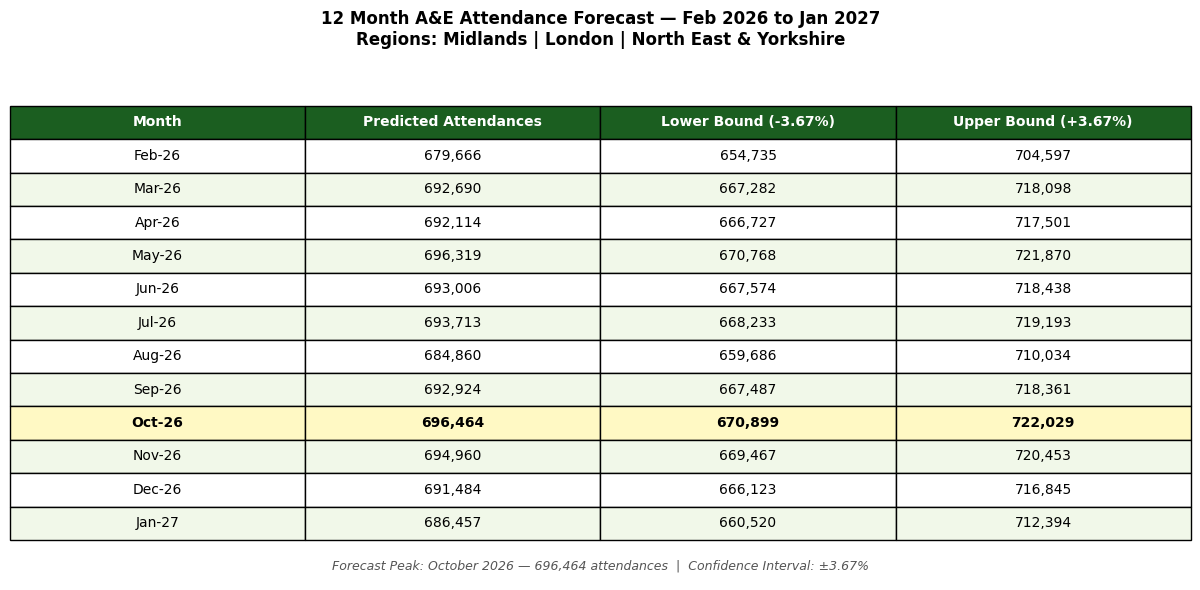

Forecast table saved as PNG!


In [ ]:

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

table_data = [
    ['Month', 'Predicted Attendances', 'Lower Bound (-3.67%)', 'Upper Bound (+3.67%)'],
    ['Feb-26', '679,666', '654,735', '704,597'],
    ['Mar-26', '692,690', '667,282', '718,098'],
    ['Apr-26', '692,114', '666,727', '717,501'],
    ['May-26', '696,319', '670,768', '721,870'],
    ['Jun-26', '693,006', '667,574', '718,438'],
    ['Jul-26', '693,713', '668,233', '719,193'],
    ['Aug-26', '684,860', '659,686', '710,034'],
    ['Sep-26', '692,924', '667,487', '718,361'],
    ['Oct-26', '696,464', '670,899', '722,029'],  # peak
    ['Nov-26', '694,960', '669,467', '720,453'],
    ['Dec-26', '691,484', '666,123', '716,845'],
    ['Jan-27', '686,457', '660,520', '712,394'],
]

tbl = ax.table(cellText=table_data[1:],
               colLabels=table_data[0],
               cellLoc='center',
               loc='center')

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# Header styling
for j in range(4):
    tbl[0, j].set_facecolor('#1B5E20')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Row styling
for i in range(1, 13):
    for j in range(4):
        if i == 9:  # October peak row
            tbl[i, j].set_facecolor('#FFF9C4')
            tbl[i, j].set_text_props(fontweight='bold')
        elif i % 2 == 0:
            tbl[i, j].set_facecolor('#F1F8E9')
        else:
            tbl[i, j].set_facecolor('#FFFFFF')

# Peak label
ax.text(0.5, 0.02,
        'Forecast Peak: October 2026 — 696,464 attendances  |  Confidence Interval: ±3.67%',
        transform=ax.transAxes, fontsize=9, ha='center',
        style='italic', color='#555555')

plt.title('12 Month A&E Attendance Forecast — Feb 2026 to Jan 2027\nRegions: Midlands | London | North East & Yorkshire',
          fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('forecast_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Forecast table saved as PNG!")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

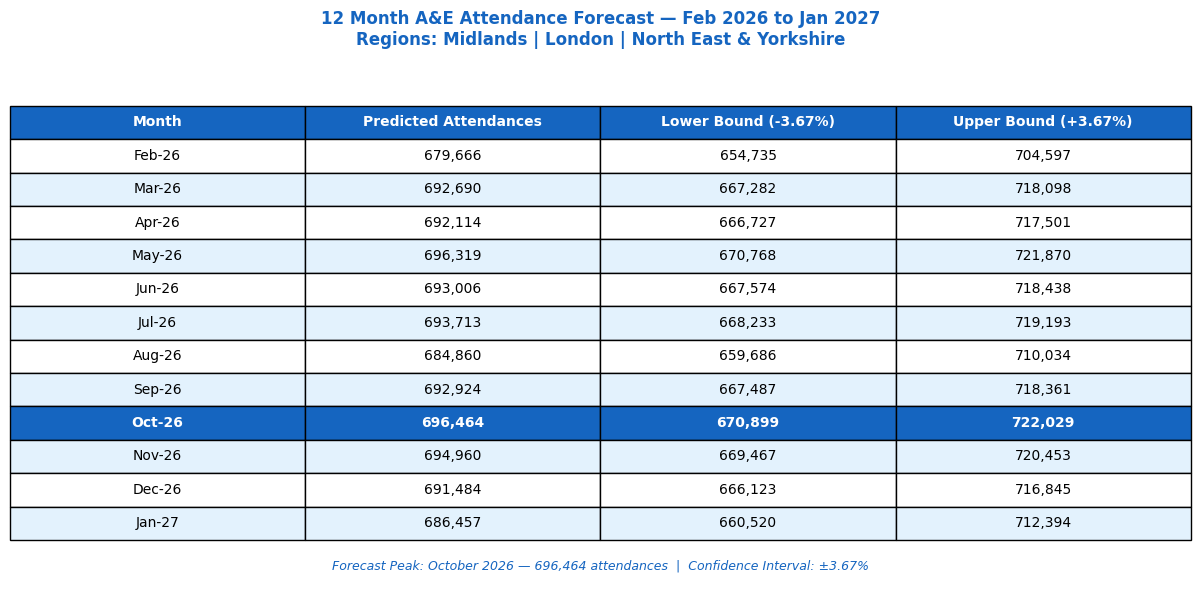

Blue and white forecast table saved!


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

table_data = [
    ['Month', 'Predicted Attendances', 'Lower Bound (-3.67%)', 'Upper Bound (+3.67%)'],
    ['Feb-26', '679,666', '654,735', '704,597'],
    ['Mar-26', '692,690', '667,282', '718,098'],
    ['Apr-26', '692,114', '666,727', '717,501'],
    ['May-26', '696,319', '670,768', '721,870'],
    ['Jun-26', '693,006', '667,574', '718,438'],
    ['Jul-26', '693,713', '668,233', '719,193'],
    ['Aug-26', '684,860', '659,686', '710,034'],
    ['Sep-26', '692,924', '667,487', '718,361'],
    ['Oct-26', '696,464', '670,899', '722,029'],
    ['Nov-26', '694,960', '669,467', '720,453'],
    ['Dec-26', '691,484', '666,123', '716,845'],
    ['Jan-27', '686,457', '660,520', '712,394'],
]

tbl = ax.table(cellText=table_data[1:],
               colLabels=table_data[0],
               cellLoc='center',
               loc='center')

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# Header — dark blue
for j in range(4):
    tbl[0, j].set_facecolor('#1565C0')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Row styling — blue and white alternating
for i in range(1, 13):
    for j in range(4):
        if i == 9:  # October peak
            tbl[i, j].set_facecolor('#1565C0')
            tbl[i, j].set_text_props(color='white', fontweight='bold')
        elif i % 2 == 0:
            tbl[i, j].set_facecolor('#E3F2FD')  # light blue
        else:
            tbl[i, j].set_facecolor('#FFFFFF')  # white

ax.text(0.5, 0.02,
        'Forecast Peak: October 2026 — 696,464 attendances  |  Confidence Interval: ±3.67%',
        transform=ax.transAxes, fontsize=9, ha='center',
        style='italic', color='#1565C0')

plt.title('12 Month A&E Attendance Forecast — Feb 2026 to Jan 2027\nRegions: Midlands | London | North East & Yorkshire',
          fontsize=12, fontweight='bold', color='#1565C0', pad=15)

plt.tight_layout()
plt.savefig('forecast_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Blue and white forecast table saved!")